# **Task 3: The Smoking Gun**

---

Task 2 did not end the way I expected but I think I interpreted the results fairly well.

Task 3 is asking to find three samples where a Human was labelled as AI. There is an obvious problem: there are no such samples because the model never got it wrong on the test set. This is a good problem to have on paper, but I can't do the analysis as originally planned. Hence, I have to adapt the methodology to still get insights about how the model makes its decisions.

1. I will perform Saliency analysis on correctly classified samples. Integrated Gradients attributions will show which tokens the model actually relied on for each class. This will help me determine if the model is detecting specific AI-isms, or if it is reading sentence rhythm.

2. Since there are no misclassifications, I will find the correctly classified samples where the model was **least confident**. These are the most human-like AI paragraphs and the most AI-like human paragraphs. This will probably be more informative than three random errors would have been.

3. I will construct adversarial paragraphs to challenge the model and watch where its confidence drops.

Integrated Gradients was introduced in the paper [Axiomatic attribution for deep networks](https://arxiv.org/pdf/1703.01365) by Sundararajan et al. (2017). It is a popular method for attributing the prediction of a neural network to its input features.

The idea is to see how much each token *caused* the model's prediction. I will use Captum's `IntegratedGradients` attribution algorithm (applied to the embedding layer). It will start with a baseline input (all padding tokens, i.e., zero information) and then interpolate between that and the actual input. Interpoloation means that the algo will create a series of intermediate inputs (specific points along the path) that are scaled versions of the actual input, starting from the baseline. Scaling (scale factor of 0 to 1) is done to see how the model's output changes on the path. 

Along this path, it will compute the gradients at these intermediate points and integrate them to get attribution scores for each input token. A high positive score will mean that the token pushed the model towards the predicted class and a high negative score will mean that it pushed away. The *completeness axiom* will ensure that the scores sum to the total difference in model output between the actual input and the baseline. I will check the convergence delta to verify that the approximation is accurate. A small delta (close to zero) will indicate that the attributions are a good explanation of the model's decision and a large delta will indicate that the attributions may not be reliable.
[[1]](https://arxiv.org/pdf/1703.01365) [[2]](https://towardsdatascience.com/deep-dive-into-neural-network-explanations-with-integrated-gradients-7f4b7be855a2/) [[3]](https://www.kaggle.com/discussions/general/226092) [[4]](https://captum.ai/api/layer.html) [[5]](https://medium.com/@nivedhithadm/using-captum-for-interpreting-pytorch-models-in-production-ddf91fbbd3fd) [[6]](https://captum.ai/tutorials/Bert_SQUAD_Interpret)

**My hypotheses:**

- **H1:** The model will detect specific vocabulary words that distinguish Victorian prose from modern AI-generated text. Tier B (FFNN with averaged GloVe) already achieved 100% accuracy, which means word-level signals were sufficient to separate the classes. I believe that DistilBERT also learned the same signals but with more precision.

- **H2:** Past-tense verb forms will receive the highest attribution scores for the Human class. It was evident in Task 1  that `past_tense_ratio` was the most discriminative stylometric feature (Human = 0.58 vs both AI classes < 0.15).

In [5]:
import os
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
from captum.attr import IntegratedGradients 

# Paths
MODELS_DIR  = '../models/distilbert_lora_final'
DATA_DIR    = '../data'
FIGURES_DIR = '../figures/task3'

# For reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


### **1) Loading the Tier C Model**

The *PeftModel* was saved using `.save_pretrained()`, i.e., I only have the LoRA adapter weights (not the full DistilBERT). I will now load `distilbert-base-uncased` first, then wrap it with `PeftModel.from_pretrained()`.

In [2]:
# Loading tokenizer (saved alongside the adapter)
tokenizer = AutoTokenizer.from_pretrained(MODELS_DIR)

# Loading base model and wrapping with PEFT adapter
base_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)
model = PeftModel.from_pretrained(base_model, MODELS_DIR)
model = model.to(device)
model.eval()
print('Model loaded successfully.')

label_names = {0: 'Human', 1: 'Generic AI', 2: 'Mimic AI'}

# Helper function to run a forward pass and return (pred_class, probabilities)
def get_prediction(text):
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True, # Setting 512 tokens as max length and padding to max length
        max_length=512, padding='max_length'
    ).to(device)
    with torch.no_grad(): # Saving memory because we only need the logits for prediction
        logits = model(**inputs).logits 
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy() # Converting the output to probabilities
    pred = int(np.argmax(probs)) # Getting the predicted class index
    return pred, probs

# Helper function for loading JSONL
def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

test_records = load_jsonl(os.path.join(DATA_DIR, 'splits', 'test.jsonl'))
print(f'Loaded {len(test_records)} test records.')

# Quick sanity check
correct = sum(1 for rec in test_records if get_prediction(rec['text'])[0] == rec['label'])
print(f'Test accuracy (sanity check): {correct / len(test_records) * 100:.2f}%')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`use_return_dict` is deprecated! Use `return_dict` instead!


Model loaded successfully.
Loaded 225 test records.
Test accuracy (sanity check): 100.00%


---

### **2) Saliency Mapping using Integrated Gradients**

To run Integrated Gradients, I will need a forward function that takes embedding tensors as input rather than token IDs, because Captum operates on continuous inputs. [[4]](https://captum.ai/api/layer.html)

The embedding layer maps discrete token IDs to 768-dimensional vectors. If I pass the embeddings directly, Captum can compute gradients with respect to the input embeddings and integrate along the path from the baseline (all-padding embeddings) to the actual input.

In [ ]:
# Trying to find the embedding layer because PEFT changes the access path in some cases
def get_embedding_layer(model):
    for path_fn in [
        lambda m: m.base_model.model.distilbert.embeddings,
        lambda m: m.base_model.distilbert.embeddings,
        lambda m: m.distilbert.embeddings,
    ]:
        try:
            return path_fn(model)
        except AttributeError:
            continue
    raise AttributeError(
        "Could not find embedding layer. Will need to print(model) to inspect the architecture."
    )

embedding_layer = get_embedding_layer(model)
print(f'Embedding layer: {type(embedding_layer).__name__}') # Should print "Embedding" or something similar

# Forward function for Captum ( it will take embeddings as input)
def forward_func(input_embeds, attention_mask):
    outputs = model(inputs_embeds=input_embeds, attention_mask=attention_mask) # Getting logits from the model output
    return torch.softmax(outputs.logits, dim=-1) # Returning probabilities for all the classes

# Computing Integrated Gradients attributions
def compute_attributions(text, target_class=None, n_steps=50):
    """
    Returns: tokens, attr_scores, pred_class, probs, convergence_delta
    target_class: which output class to explain. Uses predicted class if None.
    """
    # Tokenizing the input text and preparing attention masks for normal tokens and padding tokens
    inputs = tokenizer( 
        text, return_tensors='pt', truncation=True,
        max_length=512, padding='max_length'
    )
    input_ids = inputs['input_ids'].to(device) # Token IDs that will be converted to embeddings
    attention_mask = inputs['attention_mask'].to(device) # Binary mask with 1 for real tokens and 0 for padding
    actual_len = attention_mask.sum().item() # Number of real tokens (excluding padding)

    with torch.no_grad():
        logits = model(**{k: v.to(device) for k, v in inputs.items()}).logits # Raw logits for each class
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy() # Converting probabilities from shape (1, num_classes) to (num_classes,) [For Captum]
    pred_class = int(np.argmax(probs)) # Getting the predicted class index from the softmax probabilities
    if target_class is None:
        target_class = pred_class

    input_embeds = embedding_layer(input_ids) # Passing the whole batch of token IDs through the embedding layer. Shape: (1, seq_len, embed_dim). 1 is the batch size, seq_len is the length of the tokenized input (max 512) and embed_dim is 768 for DistilBERT
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id) # Tensor of shape (1, seq_len) filled with the padding token IDs (Baseline)
    baseline_embeds = embedding_layer(baseline_ids) # Shape: (1, seq_len, embed_dim). The same shape as input_embeds but all tokens are the embedding of the padding token
    
    ig = IntegratedGradients(forward_func) # Initializing the Integrated Gradients object
    attributions, delta = ig.attribute(
        inputs=input_embeds.detach(), # Preventing gradients from flowing back into the model parameters (we only want gradients w.r.t. the input embeddings)
        baselines=baseline_embeds.detach(), 
        additional_forward_args=(attention_mask,),
        target=target_class,
        return_convergence_delta=True,
        n_steps=n_steps
    )

    attr_scores = attributions.sum(dim=-1).squeeze().cpu().detach().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0][:int(actual_len)].cpu().numpy())
    attr_scores = attr_scores[:int(actual_len)] # Only keeping attribution scores for the non-padding tokens

    return tokens, attr_scores, pred_class, probs, delta.item() # Convergence delta will be a single scalar indicating the approximation error of the integrated gradients. The smaller the better (ideally close to 0)

# Visualizing token attributions as colored text (Blue = Positive Attribution towards predicted class and Red = Negative Attribution towards predicted class)
def visualize_attributions(tokens, attr_scores, pred_class, probs,
                            title='Token Attributions', save_path=None):
    
    # Normalizing attribution scores for better visualization and adding a small epsilon to prevent division by zero
    max_abs     = max(abs(attr_scores.max()), abs(attr_scores.min())) + 1e-8 
    norm_scores = attr_scores / max_abs

    # Setting up the plot
    fig, ax = plt.subplots(figsize=(20, max(2, len(tokens) // 12))) # Height based on the number of tokens (12 tokens per line)
    ax.axis('off')

    x, y = 0.0, 1.0 # Starting at the top-left corner of the plot
    line_height = 0.12 # Vertical space between lines (12% of the plot height)
    char_width  = 0.008 # Horizontal space per character (0.8% of the plot width)

    # Looping through tokens and their corresponding normalized attribution scores
    for token, score in zip(tokens, norm_scores):
        if token in ('[CLS]', '[SEP]', '[PAD]'): # Ignoring special tokens in the visualization
            continue
        if score > 0: # Positive attribution (blueish color)
            color = (1 - score * 0.8, 1 - score * 0.8, 1.0) # Darker blue for higher positive scores
        else:
            color = (1.0, 1 + score * 0.8, 1 + score * 0.8) # Darker red for higher negative scores

        clean_token = token.replace('##', '') # Removing the '##' prefix from subword tokens (tokens which are continuations of a word in BERT tokenization)
        token_width = len(clean_token) * char_width + 0.01 # Adding a small margin after each token for readability

        # Moving to the next line
        if x + token_width > 0.97:
            x  = 0.0
            y -= line_height

        # Adding the colored token text to the plot 
        ax.text(x, y, clean_token, fontsize=9,
                bbox=dict(facecolor=color, edgecolor='none', pad=2),
                transform=ax.transAxes, va='top')
        x += token_width
        if not token.startswith('##'): # Adding extra space before tokens that are not subword continuations for readability
            x += 0.004

    # Adding title with the predicted class name and probabilities for all classes
    pred_name = label_names[pred_class]
    prob_str  = '  |  '.join([f"{label_names[i]}: {probs[i]:.3f}" for i in range(3)])
    ax.set_title(f'{title}\nPredicted: {pred_name}  |  {prob_str}', fontsize=11, pad=15)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Geting the n most positively/negatively attributed content tokens
def get_top_tokens(tokens, attr_scores, n=10, direction='positive'):
    pairs = [
        (t, s) for t, s in zip(tokens, attr_scores)
        if t not in ('[CLS]', '[SEP]', '[PAD]') and not t.startswith('##')
    ]
    pairs.sort(key=lambda x: x[1], reverse=(direction == 'positive'))
    return pairs[:n]

print('Attribution functions defined.')

Embedding layer: Embeddings
Attribution functions defined.


--- Human | Topic: None ---
  Convergence delta: -0.00695


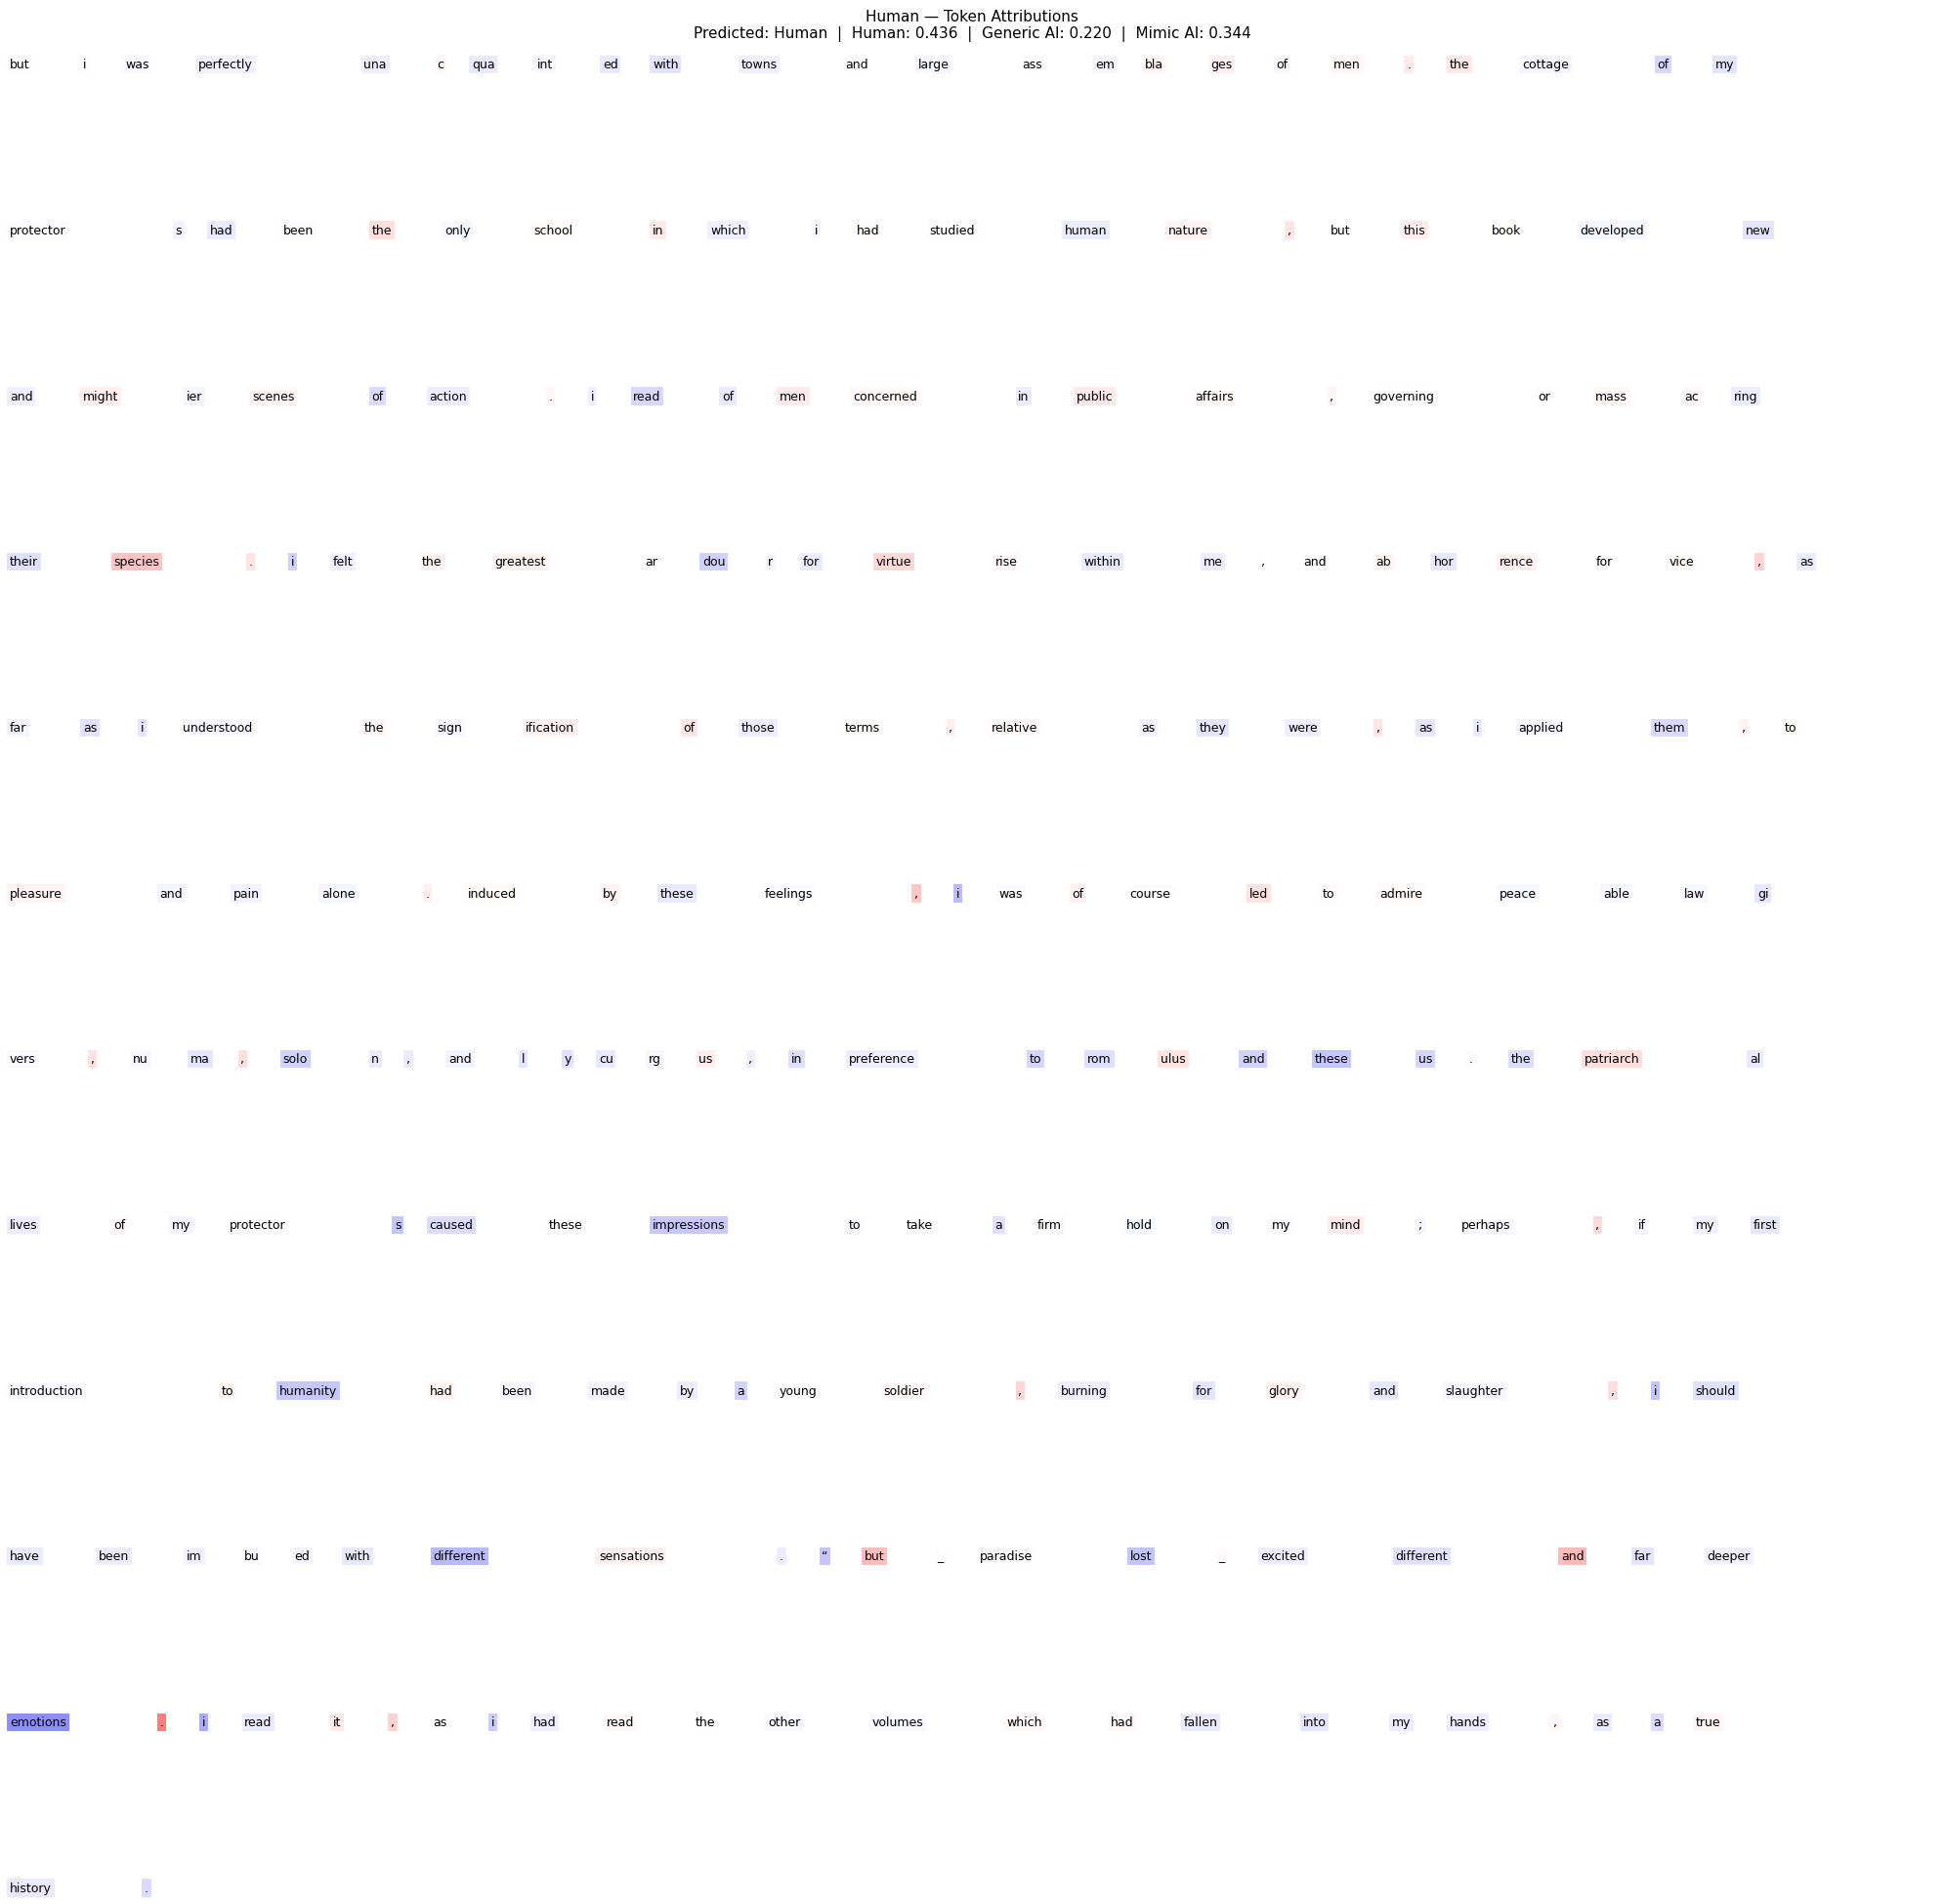

  Top positive tokens: ['emotions', 'i', 'different', 'i', 'lost', 'i', '“', 'these', 'humanity', 'impressions']

--- Generic AI | Topic: Nature and the sublime as emotional mirror ---
  Convergence delta: -0.00179


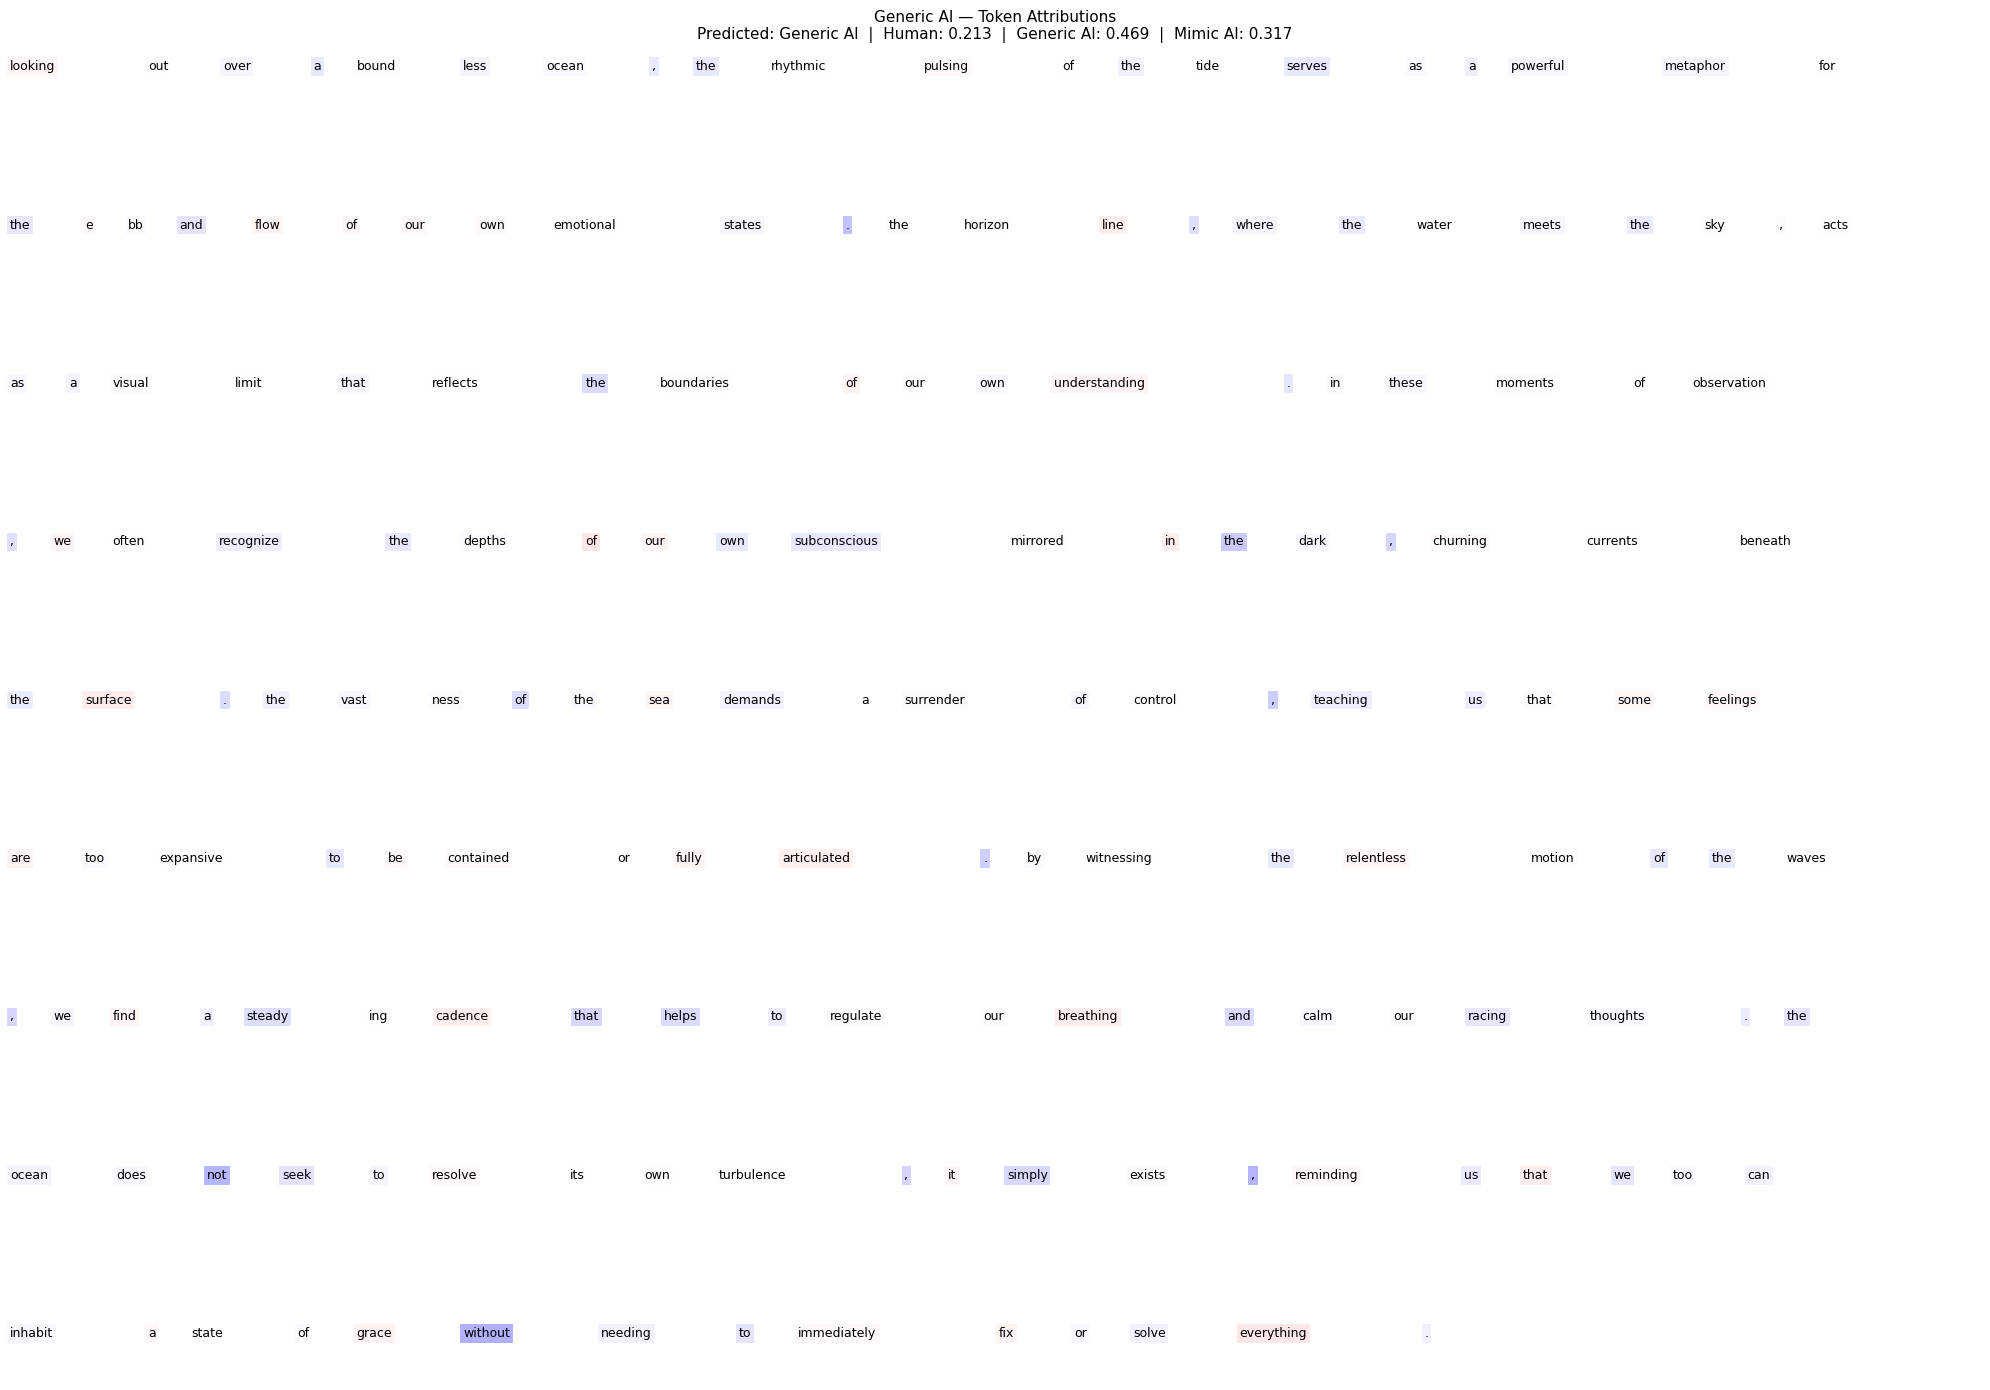

  Top positive tokens: ['without', ',', 'not', '.', 'the', ',', '.', ',', ',', ',']

--- Mimic AI | Topic: Crime, guilt, and redemption ---
  Convergence delta: -0.01393


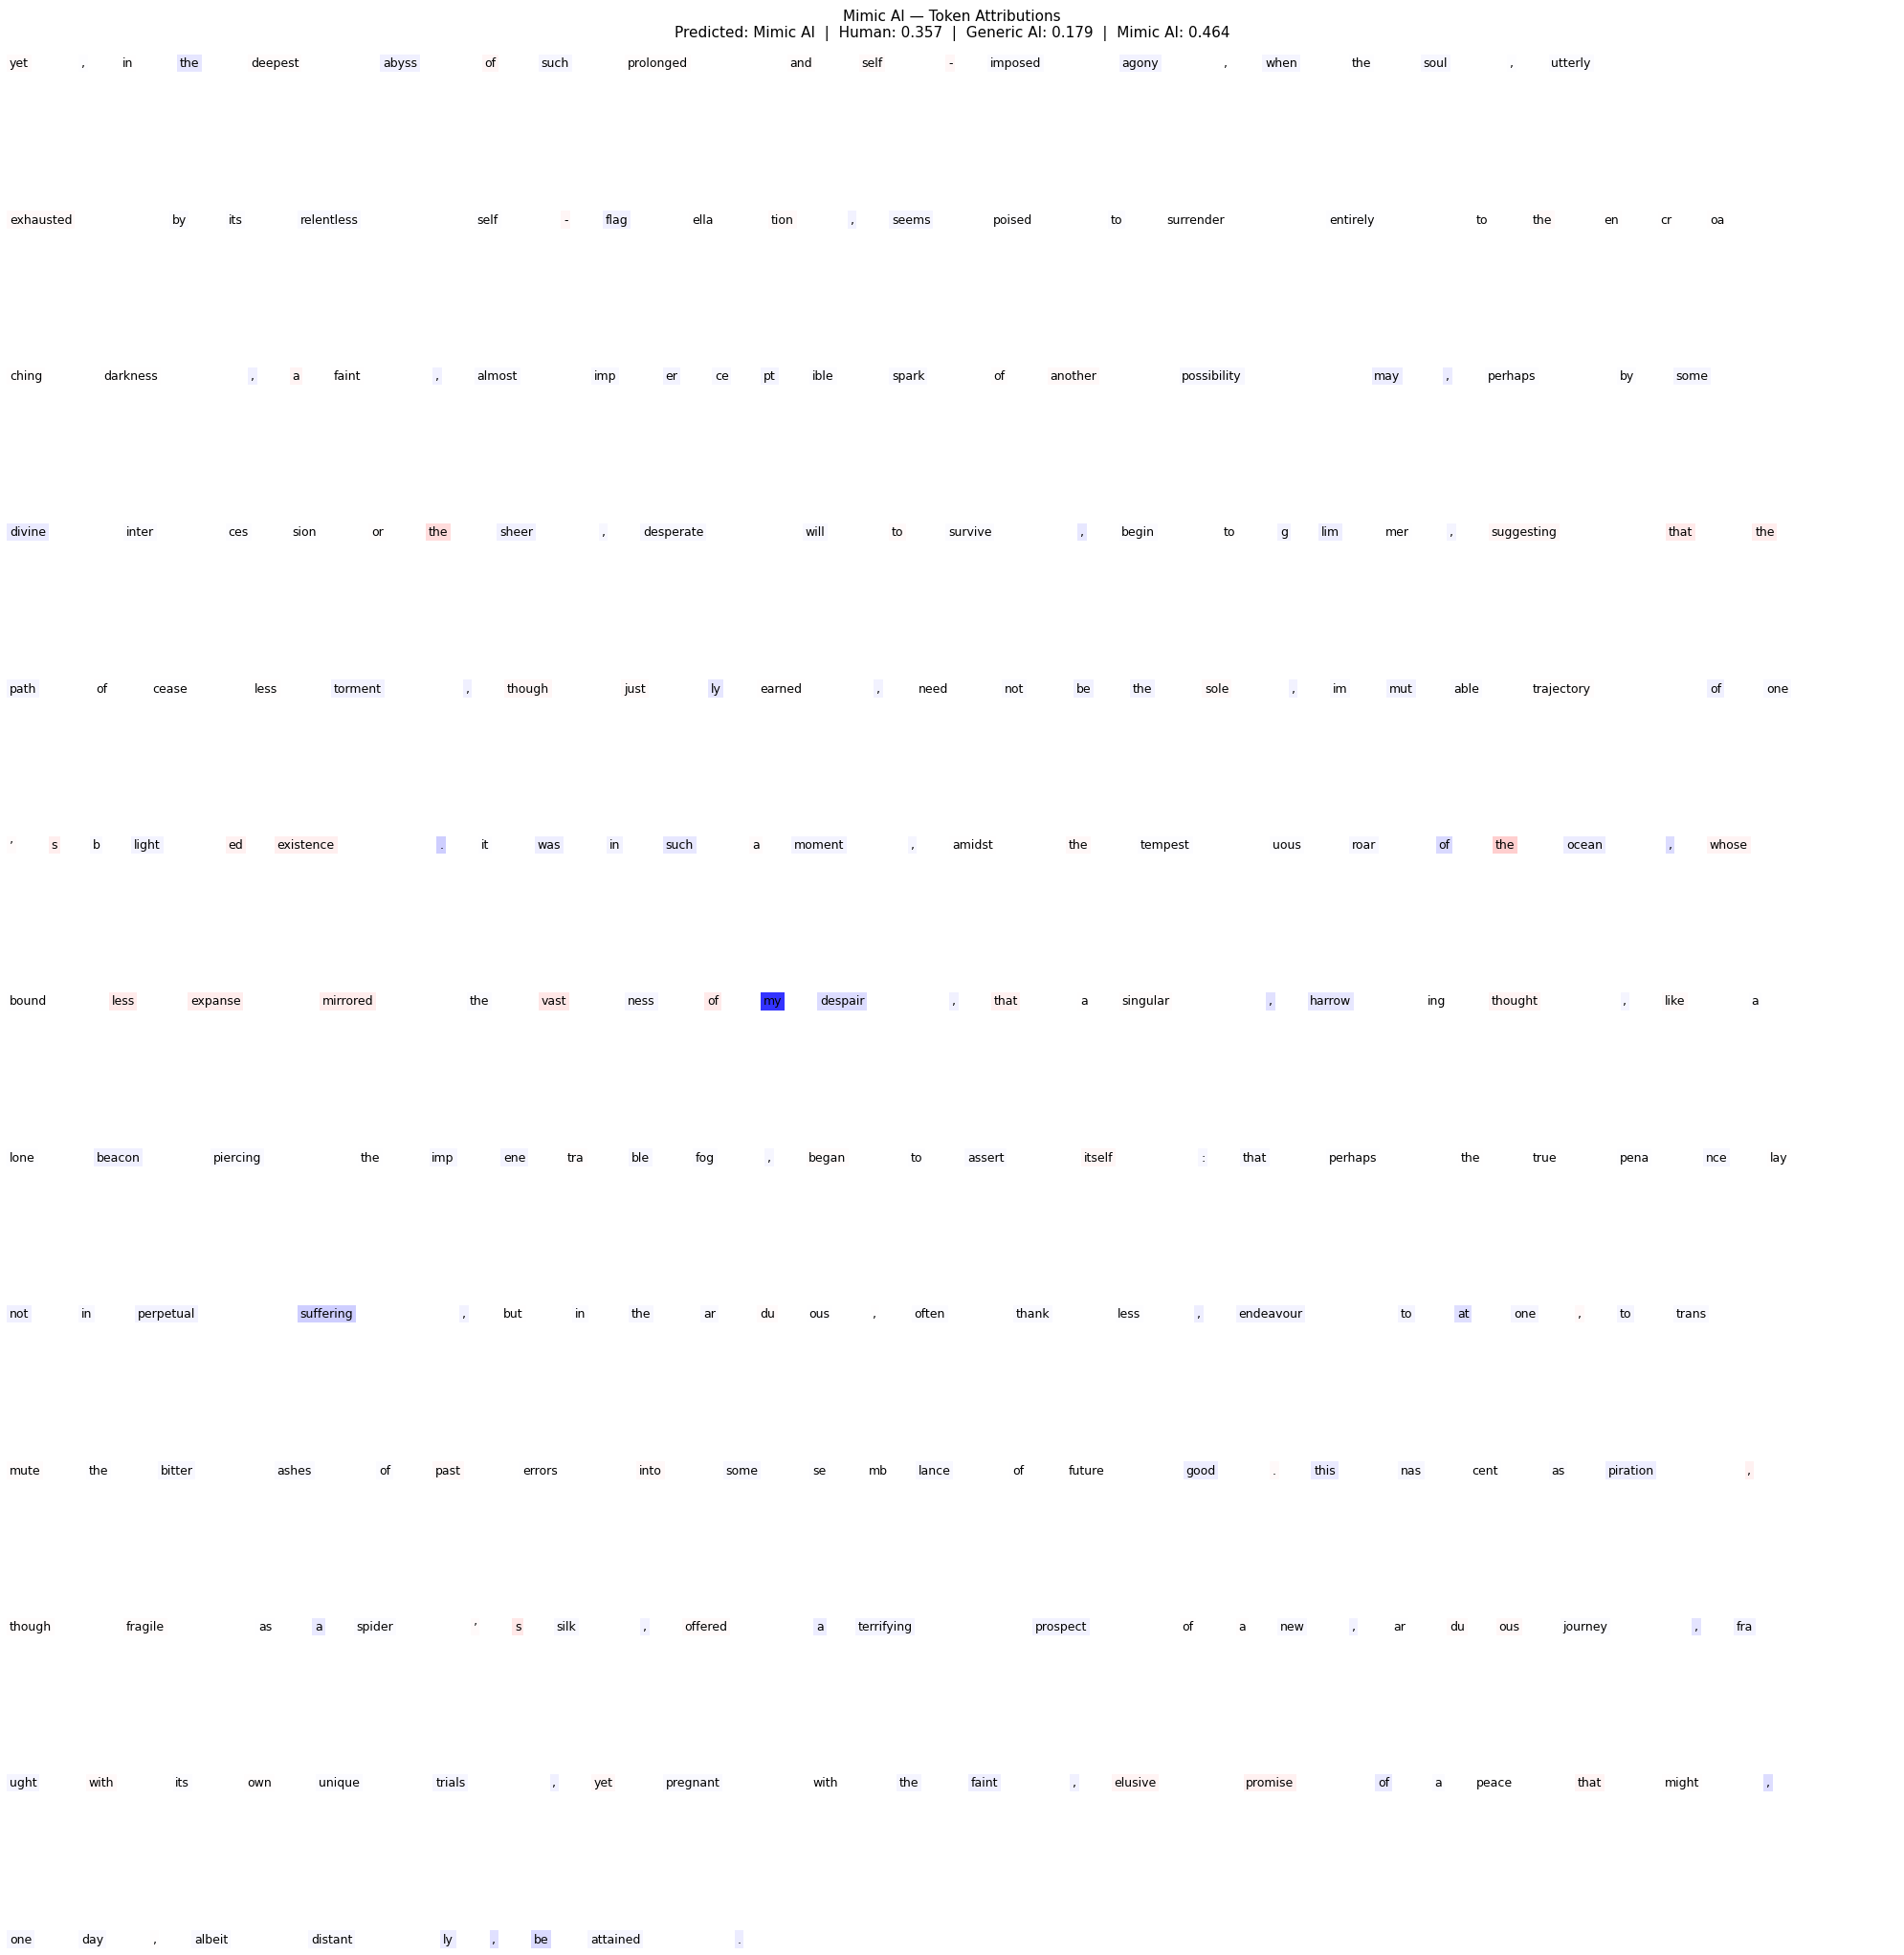

  Top positive tokens: ['my', '.', 'suffering', 'of', 'be', ',', 'despair', ',', 'at', ',']



In [ ]:
# Choosing the first occurence of a representative sample for each class in the test set
representative = {}
for rec in test_records:
    lbl = rec['label']
    if lbl not in representative:
        representative[lbl] = rec
    if len(representative) == 3: # Breaking out of loop after finding all three representatives
        break

# Running the attribution and visualization for each class
for label in [0, 1, 2]:
    rec = representative[label]
    print(f"--- {label_names[label]} | Topic: {rec.get('topic', 'N/A')} ---")
    tokens, scores, pred, probs, delta = compute_attributions(rec['text'])
    print(f"  Convergence delta: {delta:.5f}") # Should ideally be < 0.01 for good convergence
    visualize_attributions(
        tokens, scores, pred, probs,
        title=f'{label_names[label]} — Token Attributions',
        save_path=os.path.join(FIGURES_DIR, f'attribution_class{label}.png')
    )
    print(f"  Top positive tokens: {[t for t, s in get_top_tokens(tokens, scores, n=10)]}")
    print()

### **Observations on Saliency Analysis:**

I apologize for the low resolution but the attribution plots are a bit too zoomed out. Please zoom in to see the token-level details.

The plots show that the model learned different signals for each class rather than a single "AI Detector" feature.

1. **Human class:** The highest attributions are on narrative and emotional first-person words ("emotions", "humanity", "impressions", "lost"). The word "I" appearing repeatedly with high attribution makes me believe that first-person past-tense is the model's primary Human signal. I am also leaning towards this conclusion because Task 1 found `past_tense_ratio` to be the strongest discriminative feature.

2. **Generic AI:** The top attributed tokens are almost entirely punctuation marks (commas and periods) and words like "not" and "without". The model has probably learned that Generic AI uses almost no expressive punctuation because Task 1 analysis pointed out that there were zero semicolons, zero em-dashes and zero exclamations in majority of Class 2 texts' analysis. So it is possible that the model is flagging the presence of commas and periods as the only available punctuation signal.

3. **Mimic AI:** Gothic vocabulary like "suffering" and "despair" dominated the attributions. I think the model learned that this kind of vocabulary belongs to AI trying to mimic authentic Victorian proses. A counterintuitive thing is that the analysis shows"despair" as a Mimic AI signal, not a Human signal. If I have to make it make sense, I will put it like this: real Victorian authors use this vocabulary in complex past-tense sentences, while Mimic AI uses itin present-tense.

4. I can say that my first hypothesis (H1) is partially confirmed. The model is detecting both, lexical signals (Gothic vocabulary for Mimic AI) and structural signals (punctuation patterns for Generic AI). And the Human class is being detected through the narrative style.

5. Since past-tense verb forms and first person "I" have the highest attribution scores for the Human class, my second hypothesis (H2) is confirmed. 

An important thing is that convergence deltas are all negative and close to zero, which means that the attributions are a good explanation of the model's decision. 

---

### **3) The AI-isms Investigation**

I think one sample per class is not enough to draw general conclusions. I will now run attribution across 5 samples from each class, aggregate the top-10 positively attributed tokens per sample, and count how often each token appears. I am expecting that whatever shows up most frequently is what the model used as a class signal.

Samples per class: {label_names[k]: len(v) for k, v in samples_by_class.items()}

  Human: done.          
  Generic AI: done.          
  Mimic AI: done.          

--- Top positive-attribution tokens per class ---

Human — top tokens:
  '.': 7
  'i': 5
  '”': 4
  '“': 3
  'joe': 3
  'a': 2
  'and': 2
  'in': 2
  'her': 2
  '!': 2
  'emotions': 1
  'different': 1
  'lost': 1
  'these': 1
  'humanity': 1

Generic AI — top tokens:
  ',': 13
  '.': 10
  'the': 7
  'is': 3
  'not': 2
  'are': 2
  'a': 2
  'by': 2
  'without': 1
  'we': 1
  'of': 1
  'permanently': 1
  'but': 1
  'with': 1
  'feels': 1

Mimic AI — top tokens:
  ',': 16
  '.': 8
  'i': 4
  'my': 2
  'observed': 2
  'the': 2
  'suffering': 1
  'of': 1
  'be': 1
  'despair': 1
  'at': 1
  'oh': 1
  'winter': 1
  'and': 1
  'often': 1


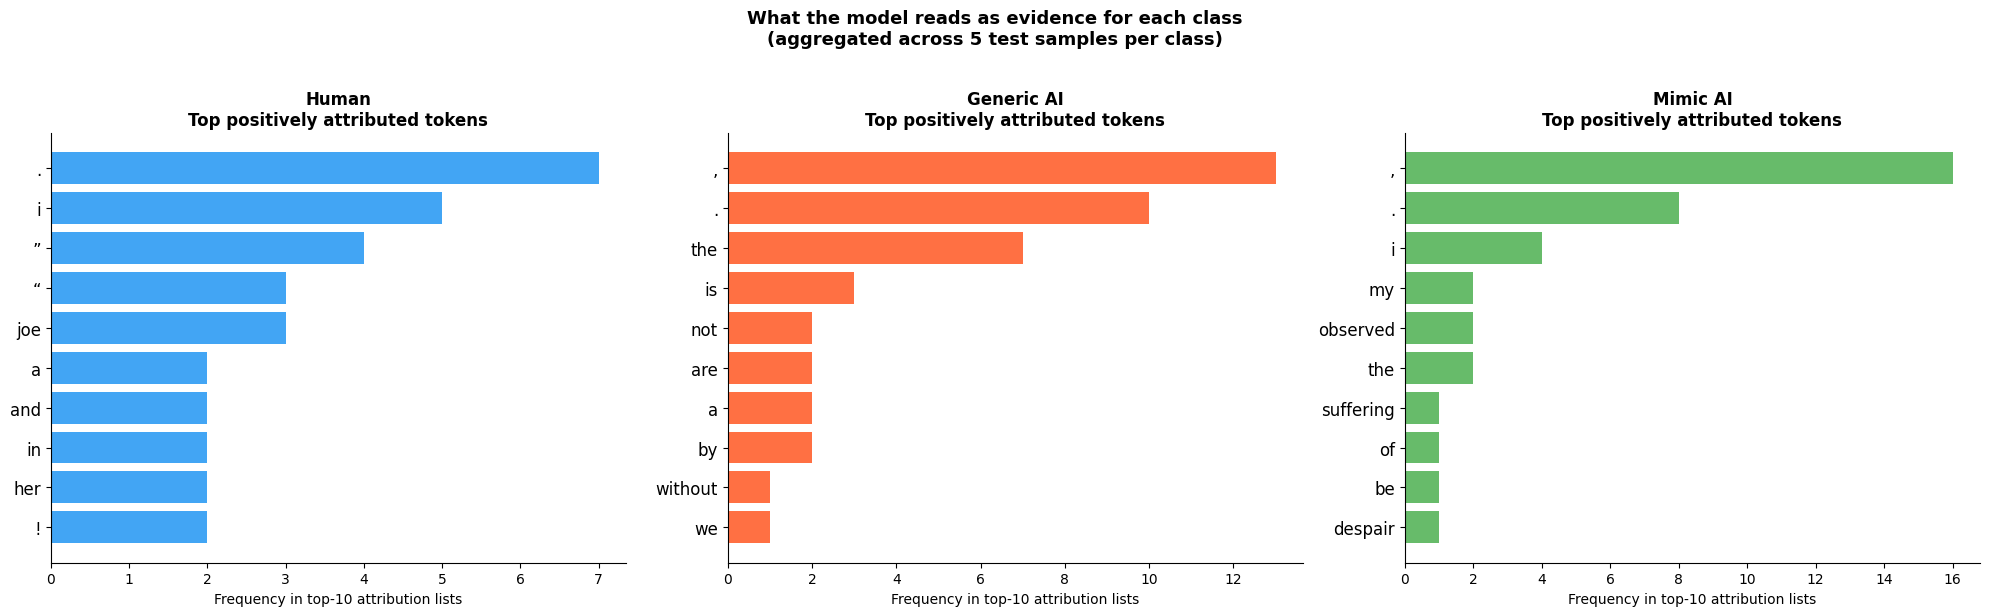

In [ ]:
# Collecting 5 samples per class
samples_by_class = {0: [], 1: [], 2: []}
for rec in test_records:
    lbl = rec['label']
    if len(samples_by_class[lbl]) < 5:
        samples_by_class[lbl].append(rec)
    if all(len(v) == 5 for v in samples_by_class.values()):
        break

print(f"Samples per class: {{label_names[k]: len(v) for k, v in samples_by_class.items()}}\n")

# Running attribution and collecting top tokens per class
all_top_positive = {0: [], 1: [], 2: []} 

# Looping through each class and its samples to compute attributions and collect top positively attributed tokens
for label, samples in samples_by_class.items(): 
    for i, rec in enumerate(samples):
        print(f"  {label_names[label]} sample {i+1}/5...", end='\r')
        tokens, scores, pred, probs, delta = compute_attributions(rec['text'])
        pos_tokens = get_top_tokens(tokens, scores, n=10, direction='positive') # If I set direction to 'negative', I will get the most negatively attributed tokens
        all_top_positive[label].extend([t for t, s in pos_tokens])
    print(f"  {label_names[label]}: done.          ")

# Printing most common positive-attribution tokens per class
print("\n--- Top positive-attribution tokens per class ---")
for label in [0, 1, 2]:
    print(f"\n{label_names[label]} — top tokens:")
    counter = Counter(all_top_positive[label])
    for tok, count in counter.most_common(15):
        print(f"  '{tok}': {count}")

# Bar chart: top 10 tokens per class
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_colors = {0: '#2196F3', 1: '#FF5722', 2: '#4CAF50'}

for idx, label in enumerate([0, 1, 2]):
    counter   = Counter(all_top_positive[label])
    top_items = counter.most_common(10)
    tok_list  = [t for t, c in top_items] # List of top 10 tokens for the class
    counts    = [c for t, c in top_items] # Corresponding counts for the top 10 tokens

    ax = axes[idx]
    ax.barh(range(len(tok_list)), counts, color=class_colors[label], alpha=0.85) # Horizontal bar chart with class-specific colors
    ax.set_yticks(range(len(tok_list)))
    ax.set_yticklabels(tok_list, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency in top-10 attribution lists', fontsize=10)
    ax.set_title(f'{label_names[label]}\nTop positively attributed tokens',
                 fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# This plot will help in understanding what kind of tokens the model is relying on as evidence for each class across multiple samples
plt.suptitle('What the model reads as evidence for each class\n(aggregated across 5 test samples per class)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'top_tokens_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

### **Observations on AI-isms Investigation**

The **Human class** flagged character names ("Joe", a Dickens character from Great Expectations, appeared 3 times), emotional content words ("emotions", "humanity"), and expressive punctuation (exclamation marks, curly quotation marks). The model probably learned that Victorian writing has named characters, emotional vocabulary, and a variety of punctuation marks. I can also recall that Generic AI had zero exclamation marks in Task 1.

I can clearly see that the **Generic AI** class flagged almost only punctuation (13 commas, 10 periods) and function words like "the" and "is". There are almost no content words in the top tokens. This is in-line with my *Saliency* section observation, just put into numbers. Generic AI is identified by what it lacks, i.e., semicolons, em-dashes, exclamations, etc.

**Mimic AI** showed 16 commas, 8 periods, and Gothic vocabulary like "suffering", "despair", "oh", "winter". The comma dominance here proved that my punctuation analysis observation of Mimic AI substituting commas for semicolons was correct. Gemini could not mimic the punctuation complexity of Victorian prose, so it overused commas instead of semicolons. But I also think Gothic words were also the important AI-isms for this class. 

If I were to conclude on the AI-isms, I would say that the model does not rely on a single mechanism. Human classification uses content words and expressive punctuation. Generic AI is detected by the absence of complex punctuation, and Mimic AI is detected by Gothic vocabulary and comma density.

Hence, there are three different signals for three different problems. This is why all my three tiers in Task 2 achieved 100% accuracy.

---

### **4) Near-Miss Analysis**

Since no samples were misclassified and I can't perform Error Analysis, I will find the samples where the model was least confident in its correct prediction . These are the paragraphs that lived closest to the decision boundary, i.e., the most human-like AI paragraphs and the most AI-like human paragraphs. If I will run my attribution function on them, they will show why the model nearly changed its mind.

In [ ]:
print("Computing confidence scores for all test records...")

all_results = [] # Master list to hold text, true label, predicted label, confidence score and probabilities for each test record
for rec in tqdm(test_records, desc='Scoring'): 
    pred, probs = get_prediction(rec['text'])
    all_results.append({
        'text':       rec['text'],
        'true_label': rec['label'],
        'pred_label': pred,
        'confidence': float(probs[pred]),
        'probs':      probs.tolist(),
        'topic':      rec.get('topic', 'N/A')
    })

# Arranging the results in ascending order of confidence
all_results.sort(key=lambda x: x['confidence'])

least_conf_human = [r for r in all_results if r['true_label'] == 0][:3] # Least confident human samples
least_conf_ai    = [r for r in all_results if r['true_label'] in (1, 2)][:3] # Least confident AI samples

print("\n--- LEAST CONFIDENT HUMAN SAMPLES (most AI-like humans) ---")
for i, r in enumerate(least_conf_human):
    print(f"\nSample {i+1}: confidence = {r['confidence']:.4f}")
    print(f"  P(Human) = {r['probs'][0]:.4f}  |  P(GenericAI) = {r['probs'][1]:.4f}  |  P(MimicAI) = {r['probs'][2]:.4f}")
    print(f"  Topic:   {r['topic']}")
    print(f"  Preview: {r['text'][:250]}...")

print("\n--- LEAST CONFIDENT AI SAMPLES (most human-like AI) ---")
for i, r in enumerate(least_conf_ai):
    print(f"\nSample {i+1}: confidence = {r['confidence']:.4f}  |  true = {label_names[r['true_label']]}")
    print(f"  P(Human) = {r['probs'][0]:.4f}  |  P(GenericAI) = {r['probs'][1]:.4f}  |  P(MimicAI) = {r['probs'][2]:.4f}")
    print(f"  Topic:   {r['topic']}")
    print(f"  Preview: {r['text'][:250]}...")

Computing confidence scores for all test records...


Scoring: 100%|██████████| 225/225 [00:29<00:00,  7.71it/s]


--- LEAST CONFIDENT HUMAN SAMPLES (most AI-like humans) ---

Sample 1: confidence = 0.4236
  P(Human) = 0.4236  |  P(GenericAI) = 0.1733  |  P(MimicAI) = 0.4031
  Topic:   None
  Preview: A new species would bless
me as its creator and source; many happy and excellent natures would
owe their being to me. No father could claim the gratitude of his
child so completely as I should deserve theirs. Pursuing these
reflections, I thought tha...

Sample 2: confidence = 0.4256
  P(Human) = 0.4256  |  P(GenericAI) = 0.1700  |  P(MimicAI) = 0.4044
  Topic:   None
  Preview: I
might tell it to the winds and to the desart heaths but I must never
among my fellow creatures, either by word or look give allowance to
the smallest conjecture of the dread reality: I must shrink before the
eye of man lest he should read my father...

Sample 3: confidence = 0.4327
  P(Human) = 0.4327  |  P(GenericAI) = 0.1625  |  P(MimicAI) = 0.4048
  Topic:   None
  Preview: What I have become since this last moment
I kno

Running attribution function on least-confident Human samples...

Human near-miss 1 — delta: 0.01802


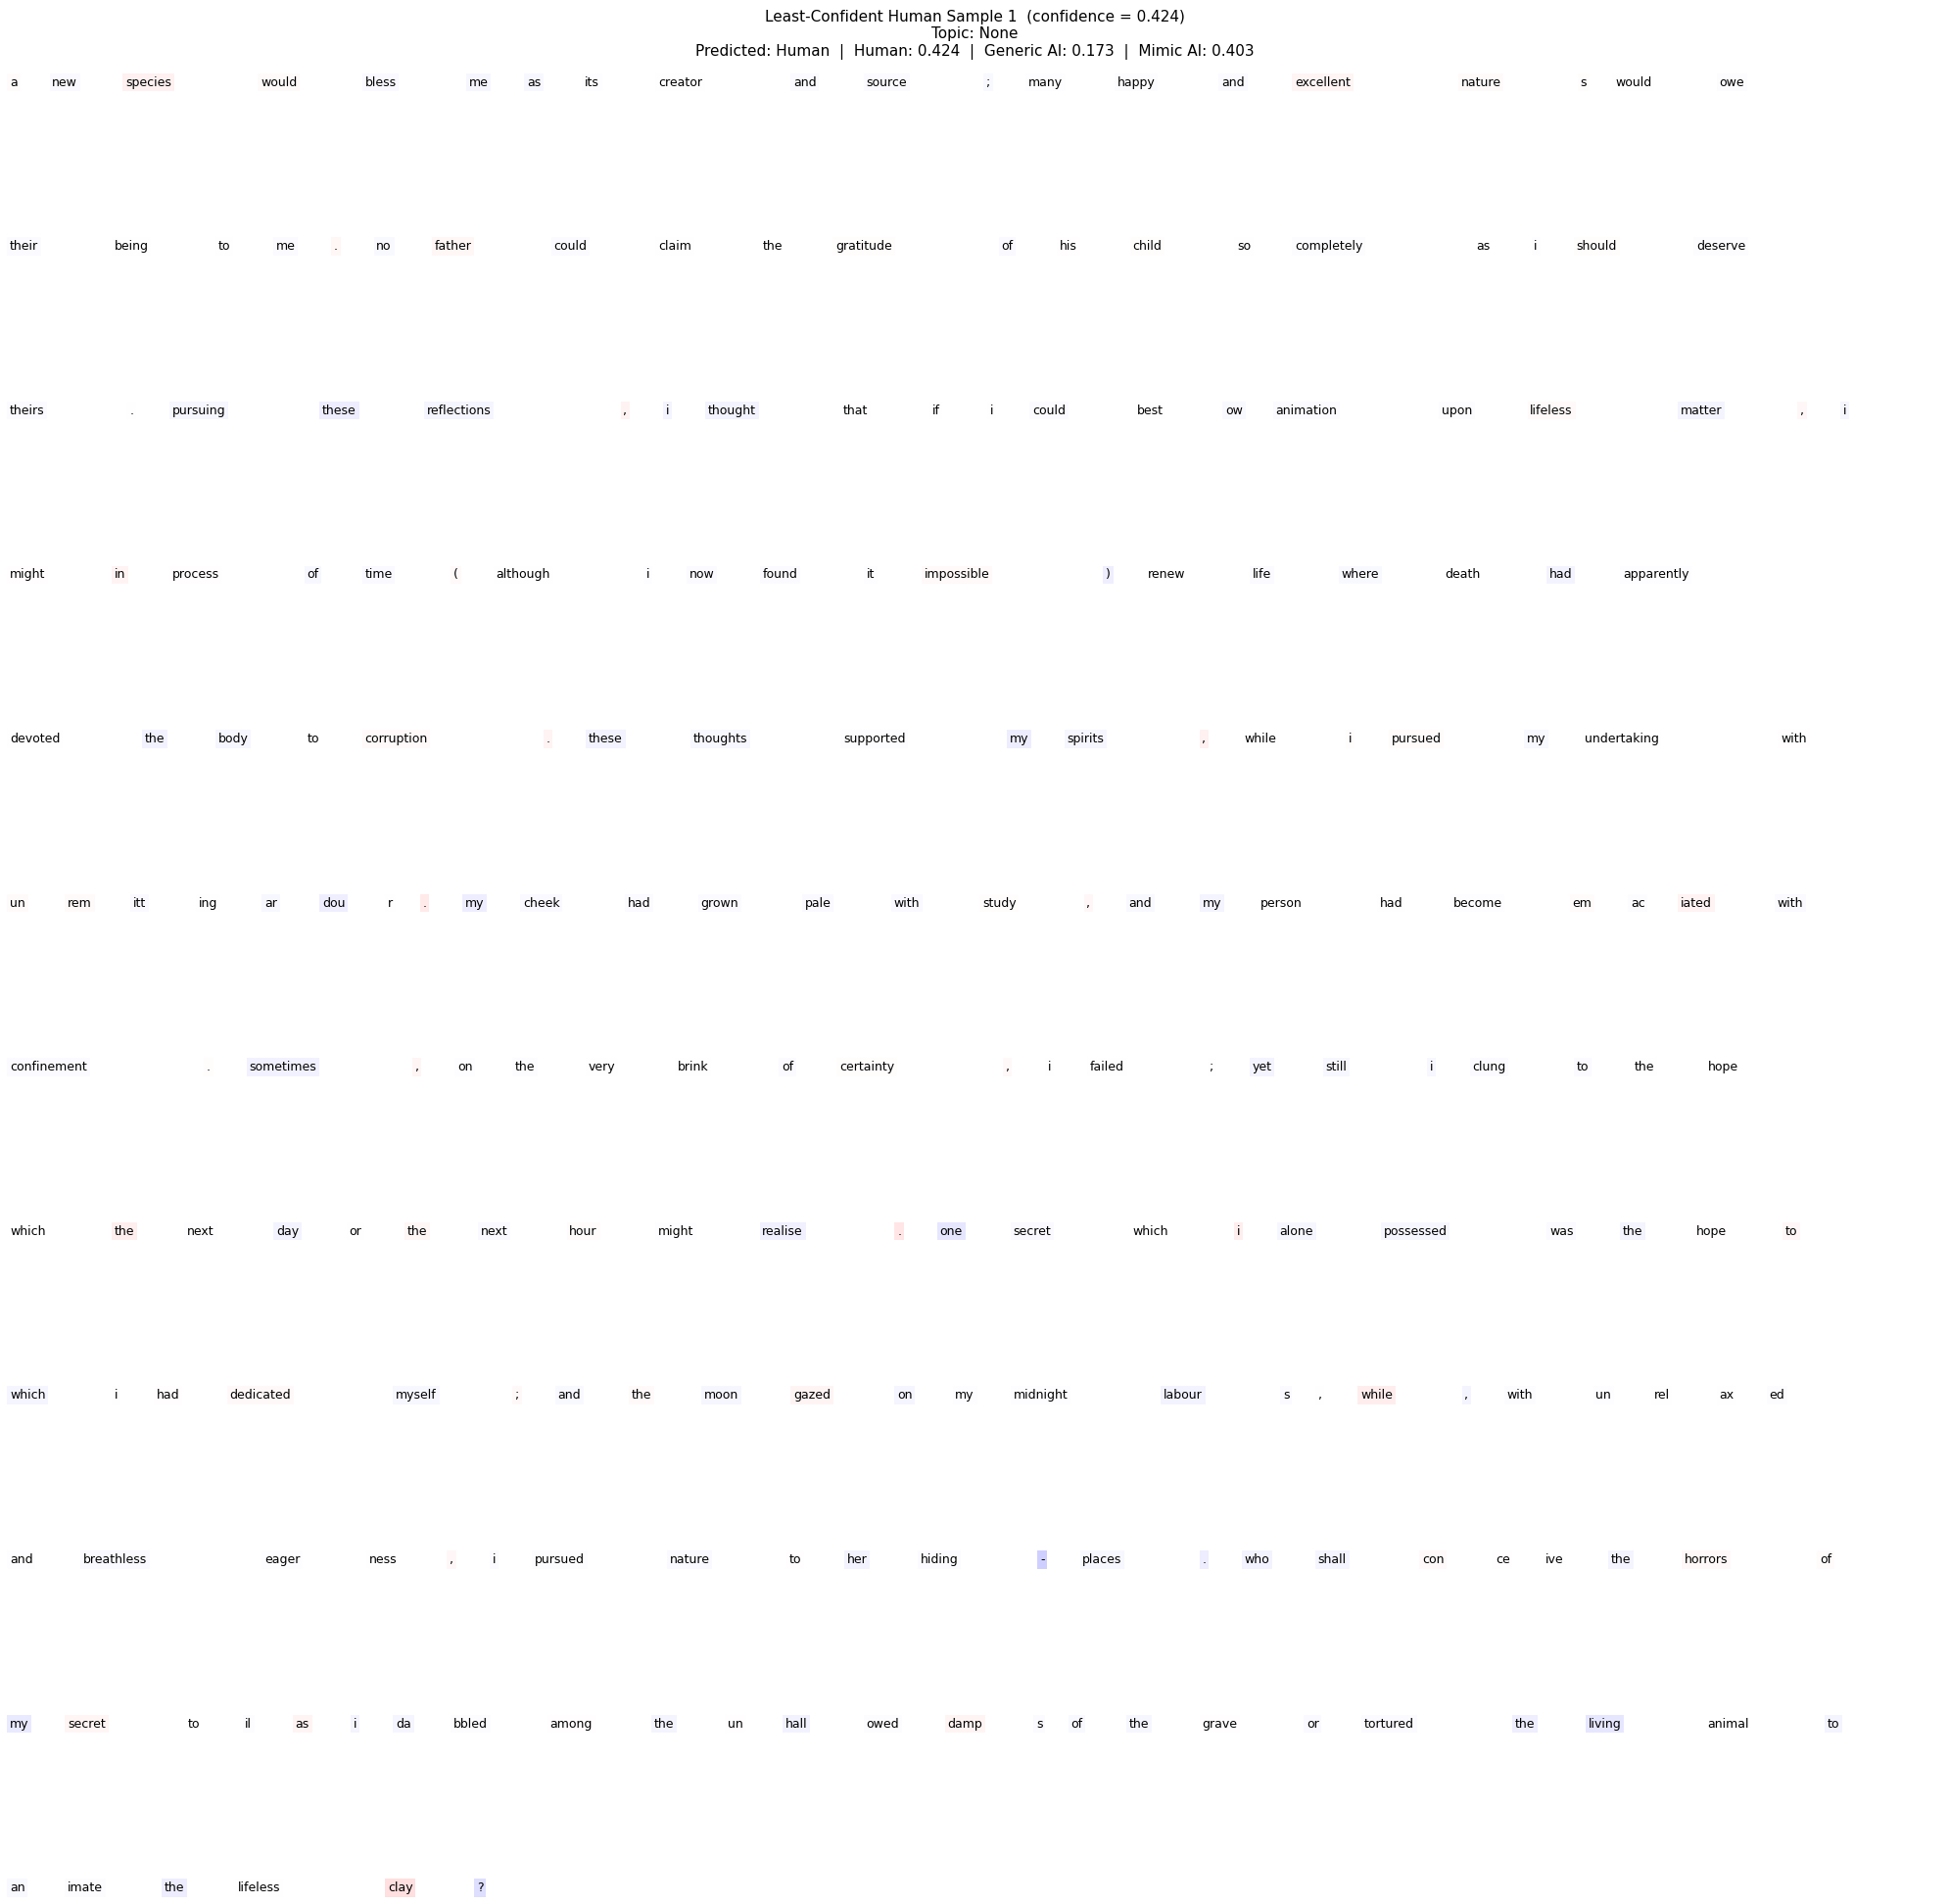


Human near-miss 2 — delta: 0.02451


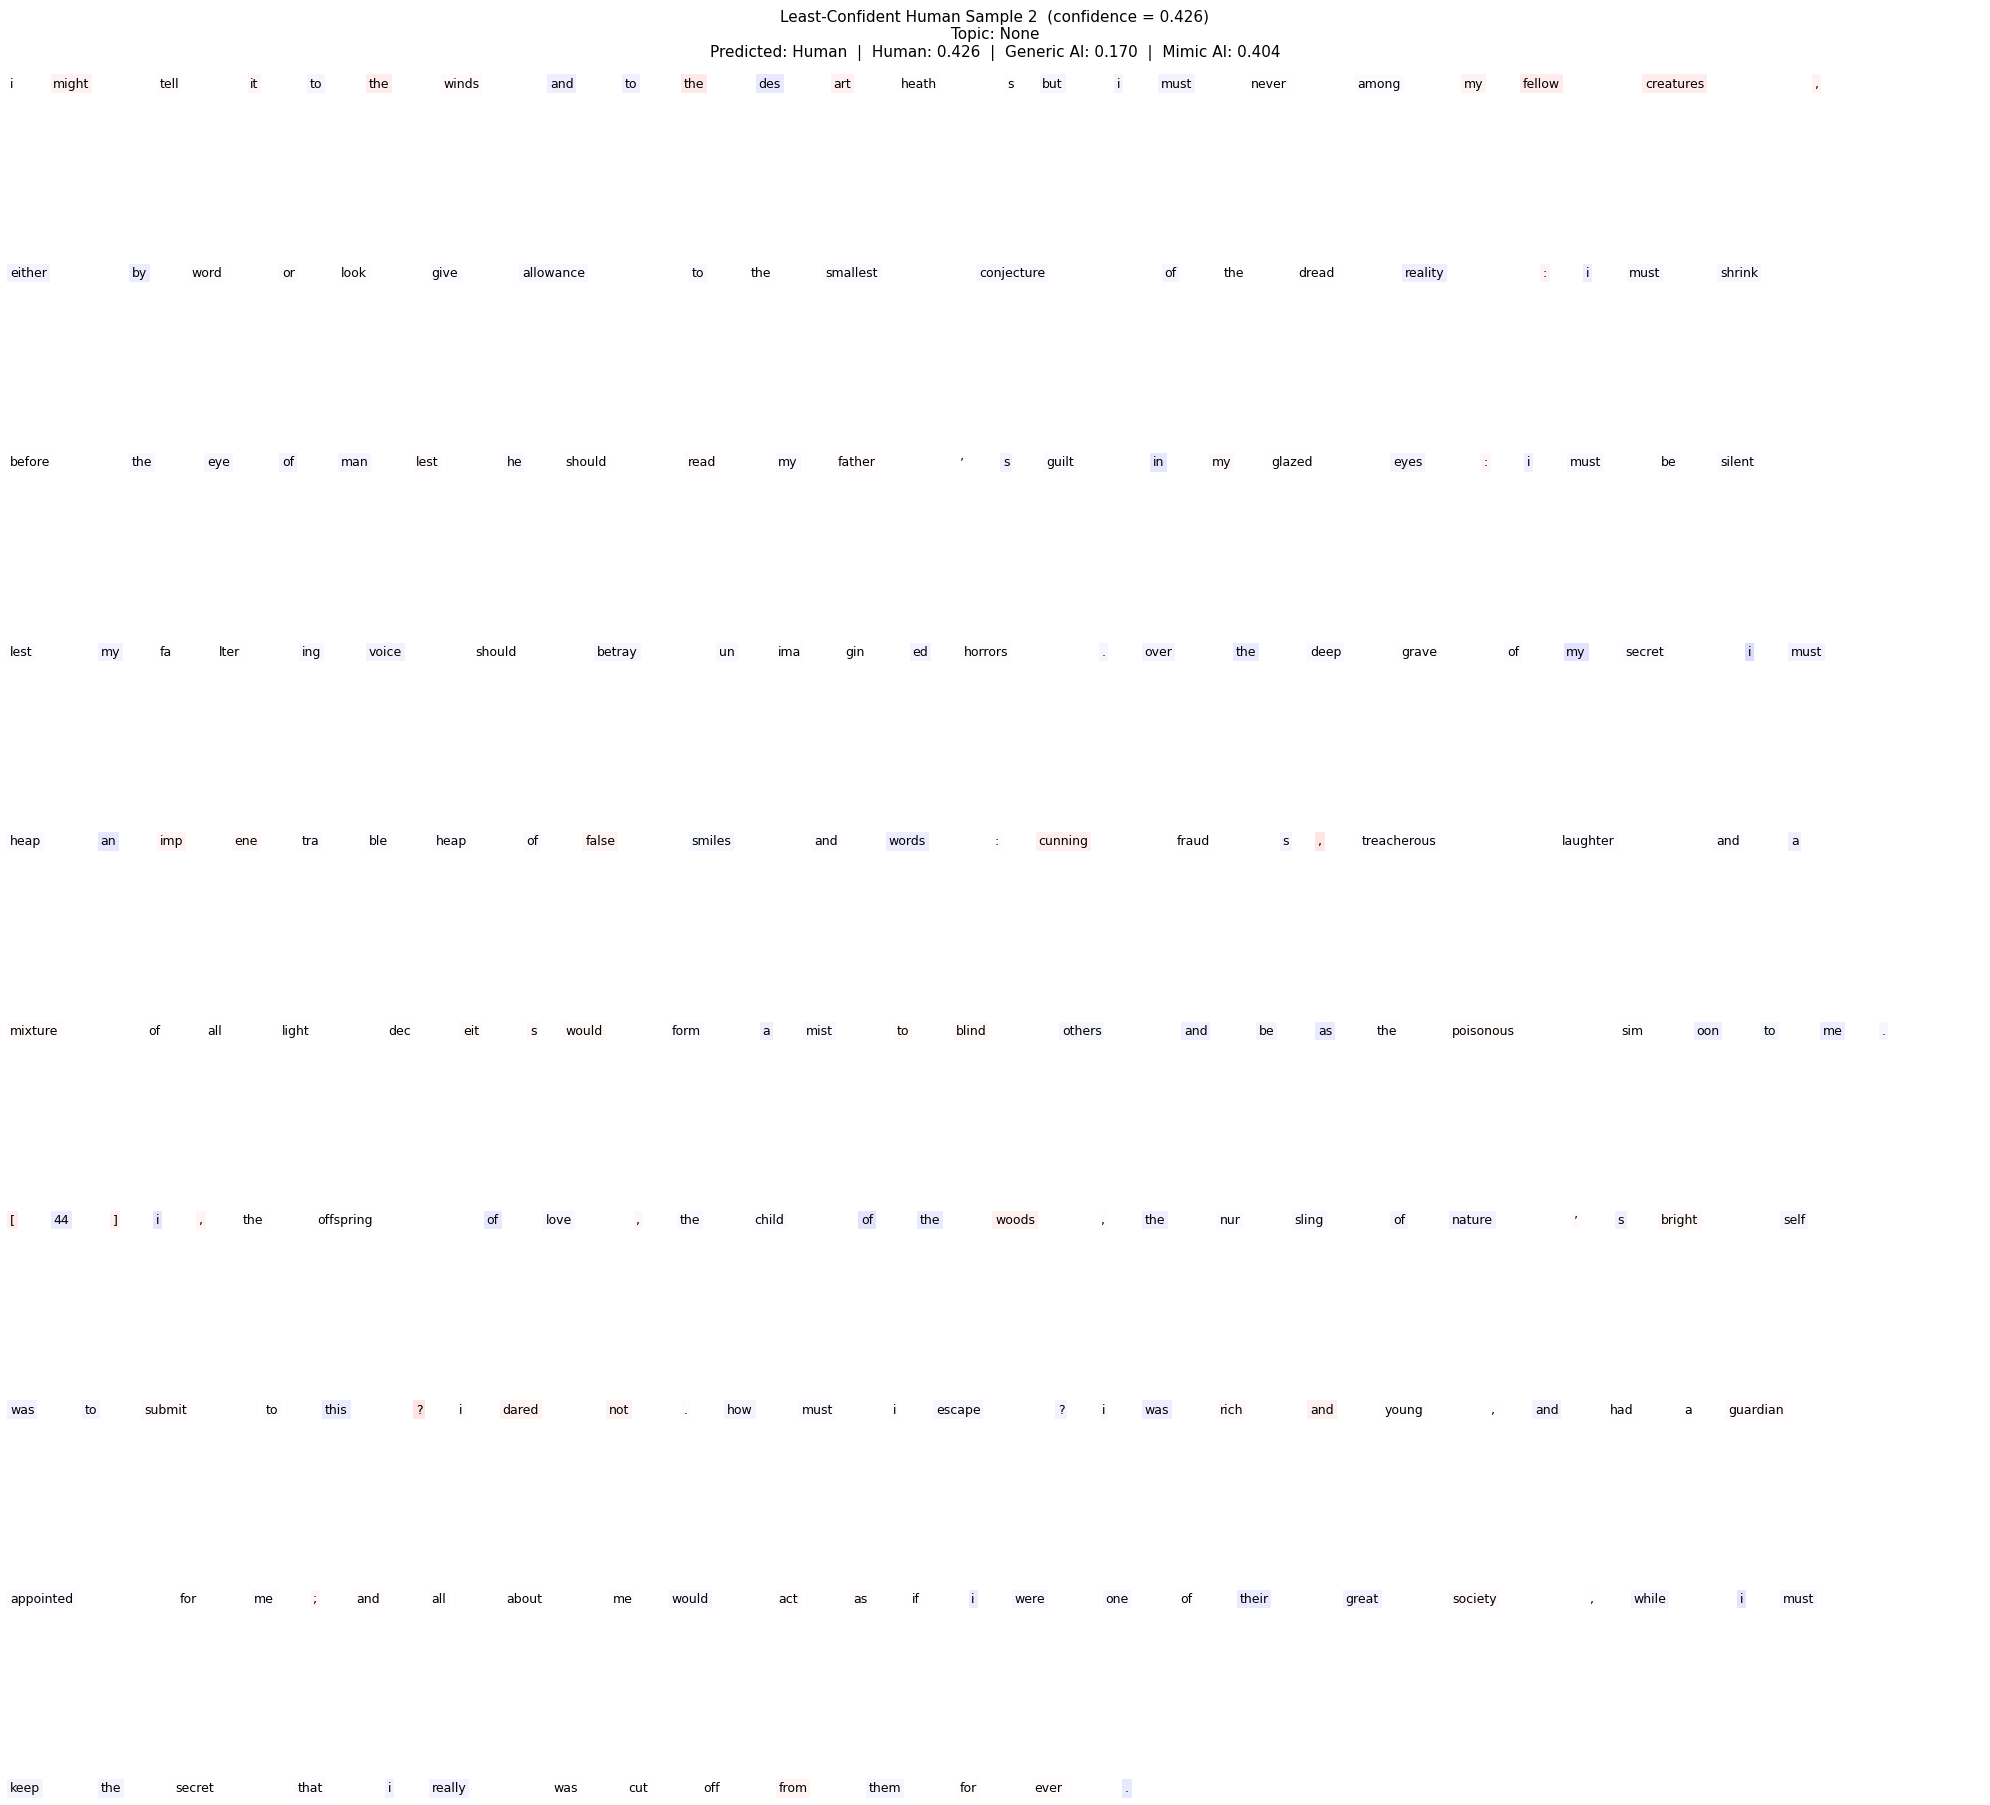


Human near-miss 3 — delta: -0.03021


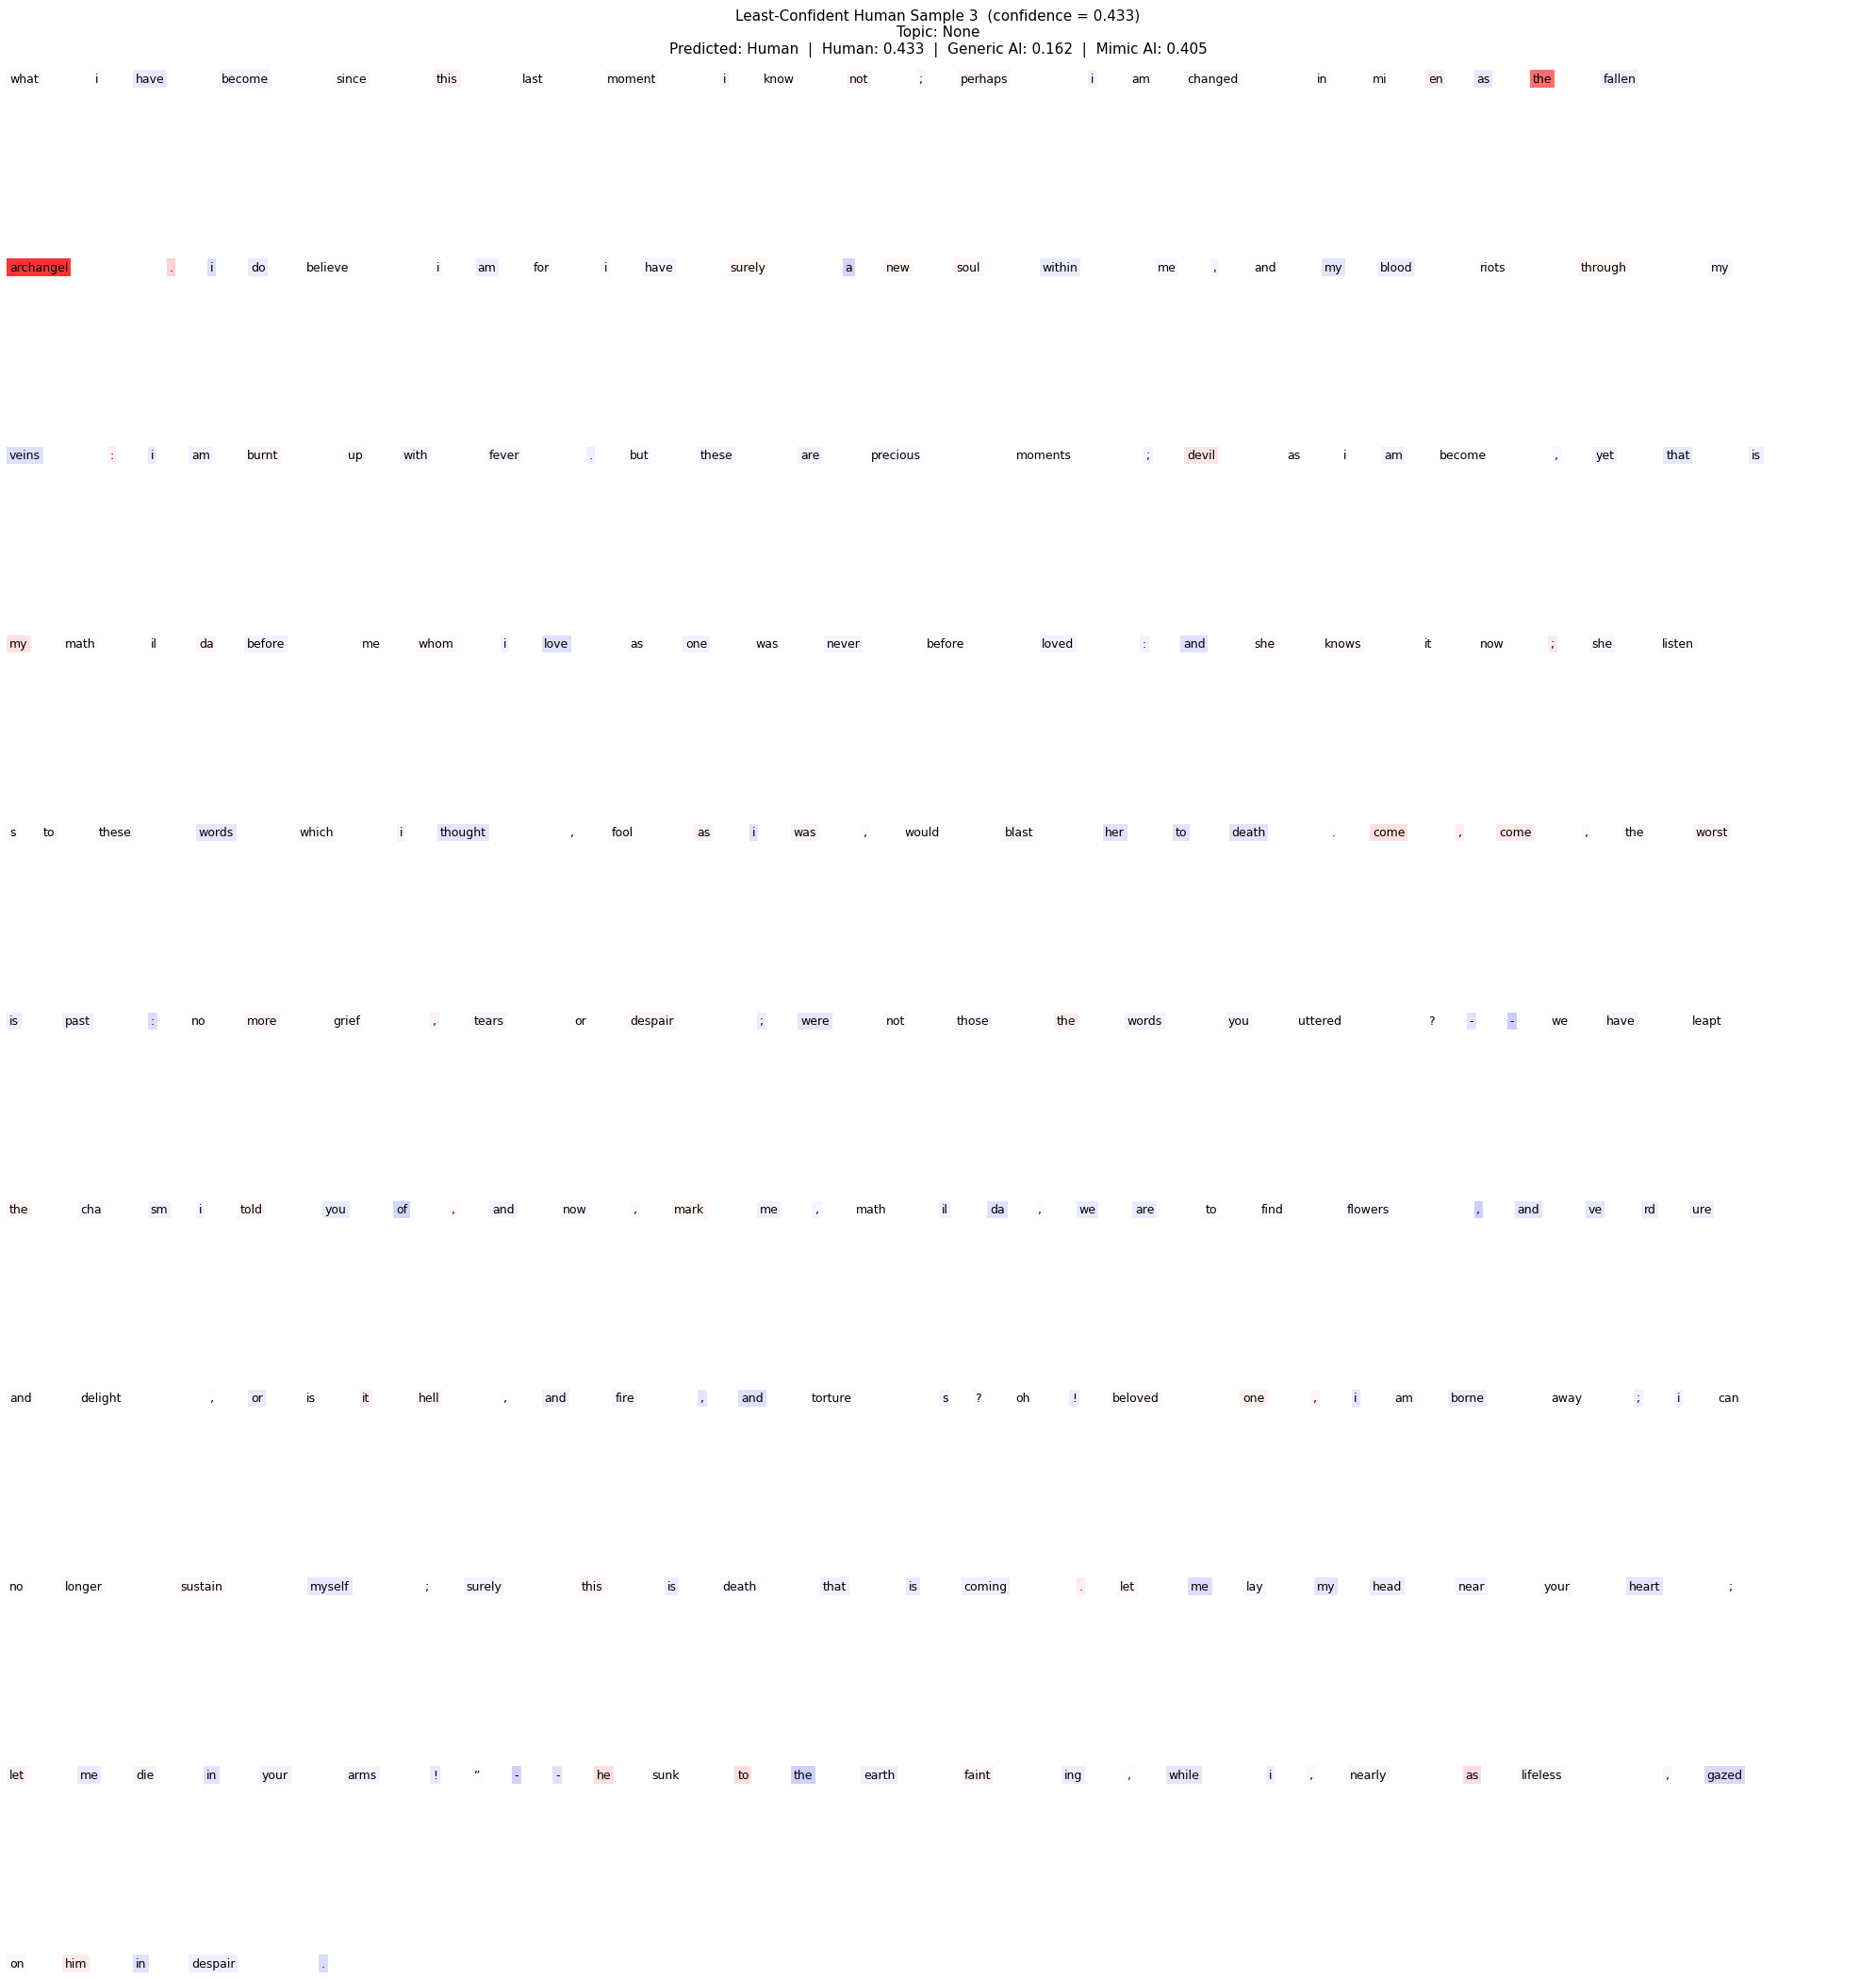

Running attribution function on least-confident AI samples...

AI near-miss 1 (Generic AI) — delta: 0.00211


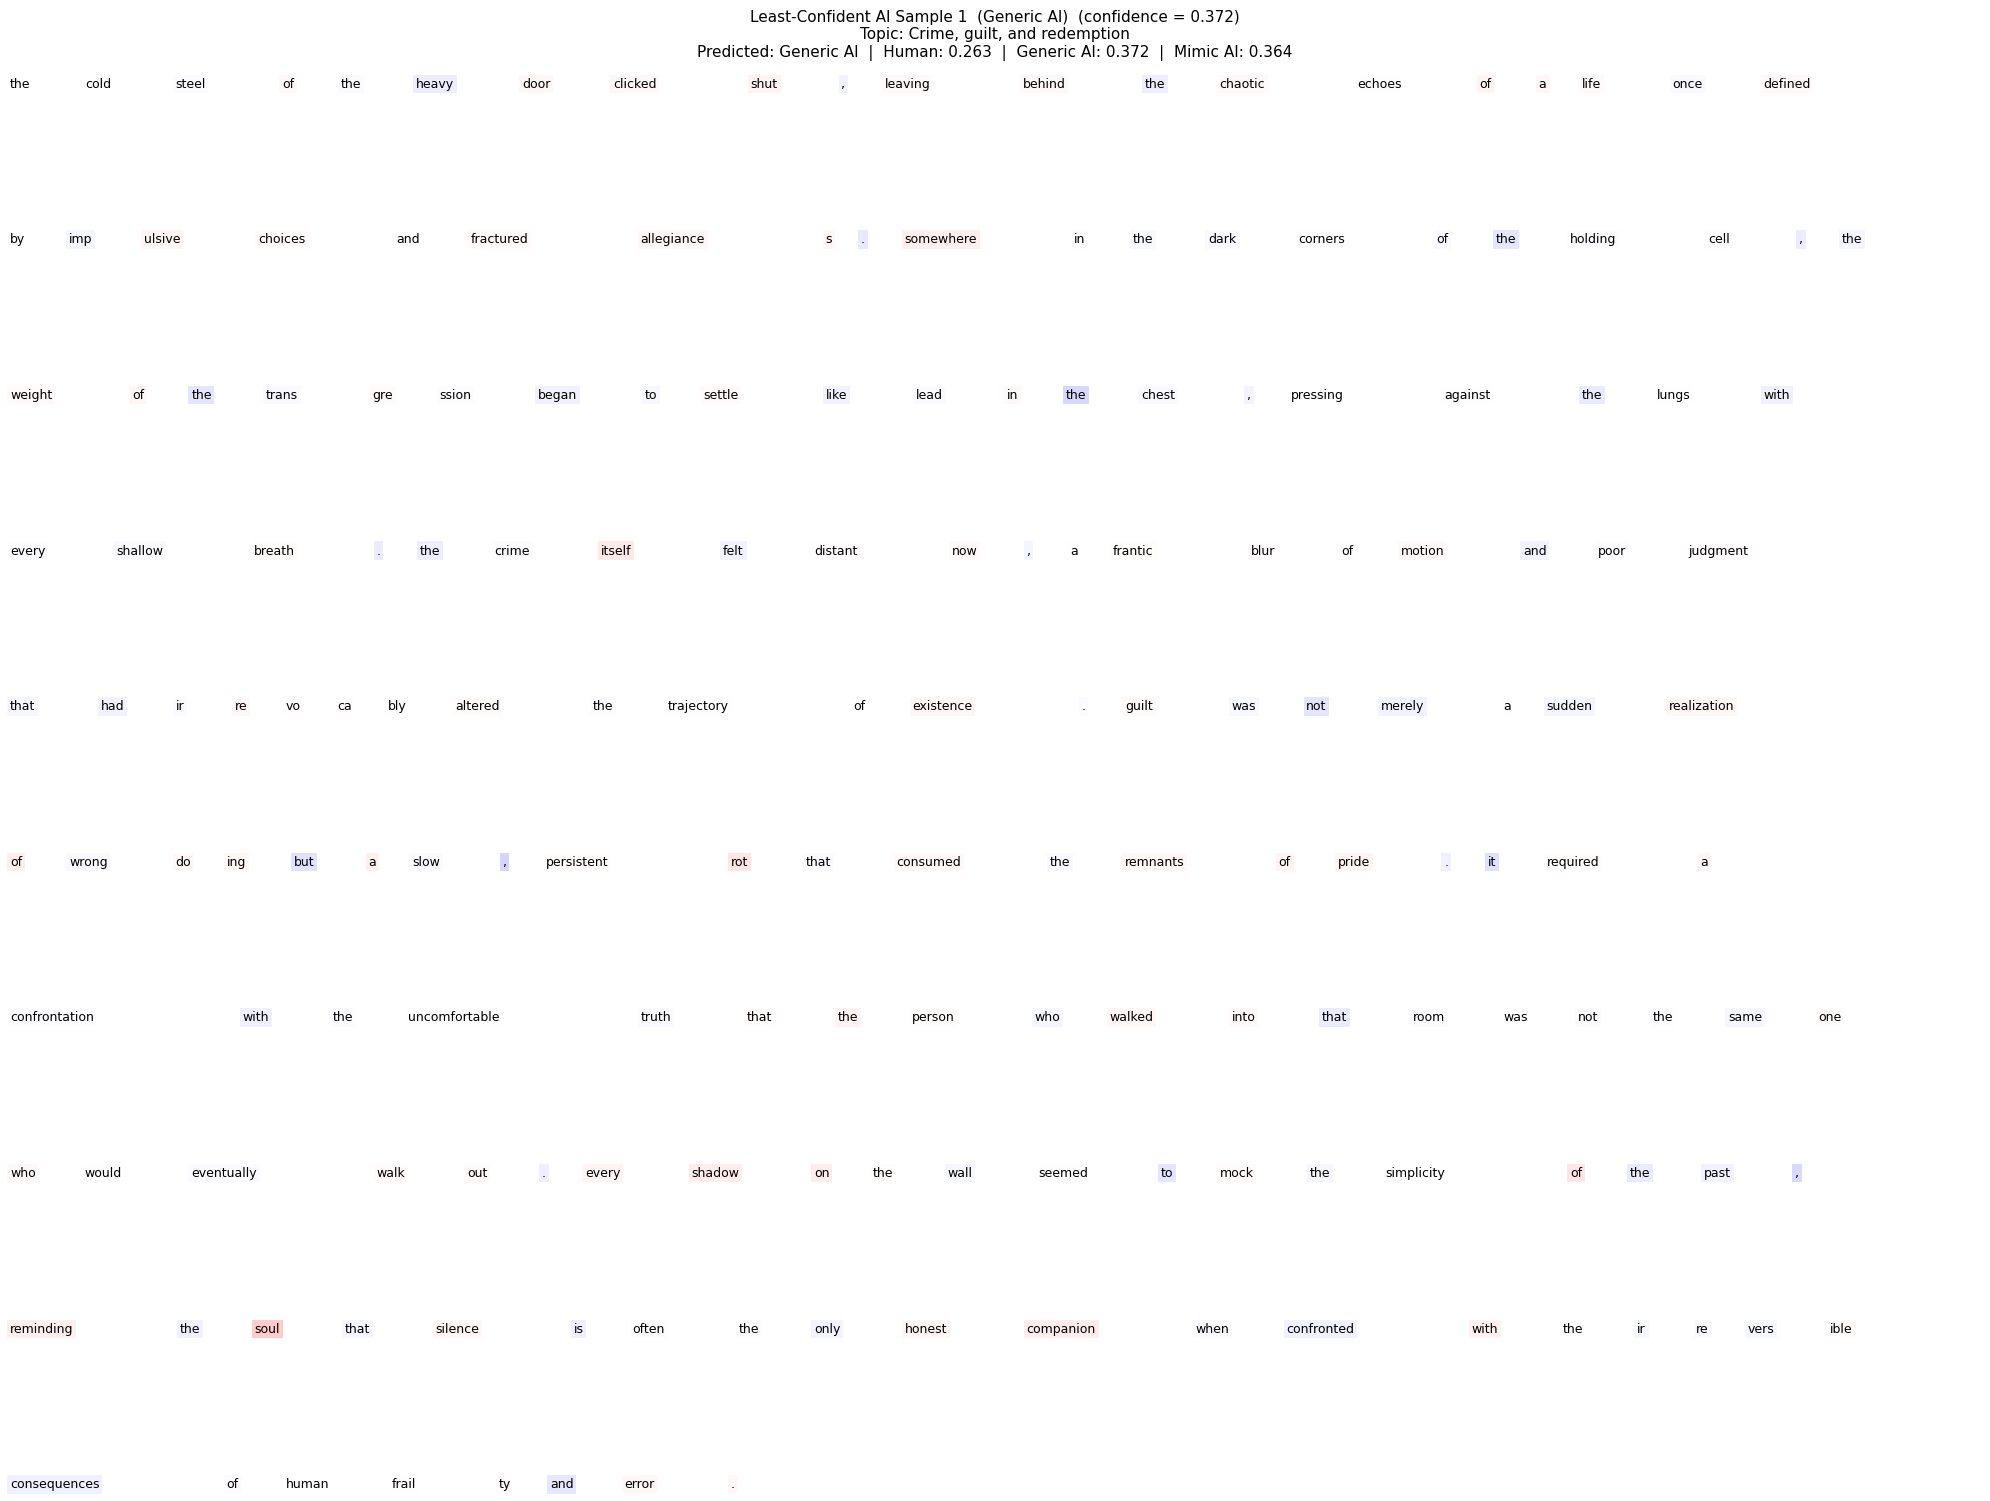


AI near-miss 2 (Generic AI) — delta: -0.02446


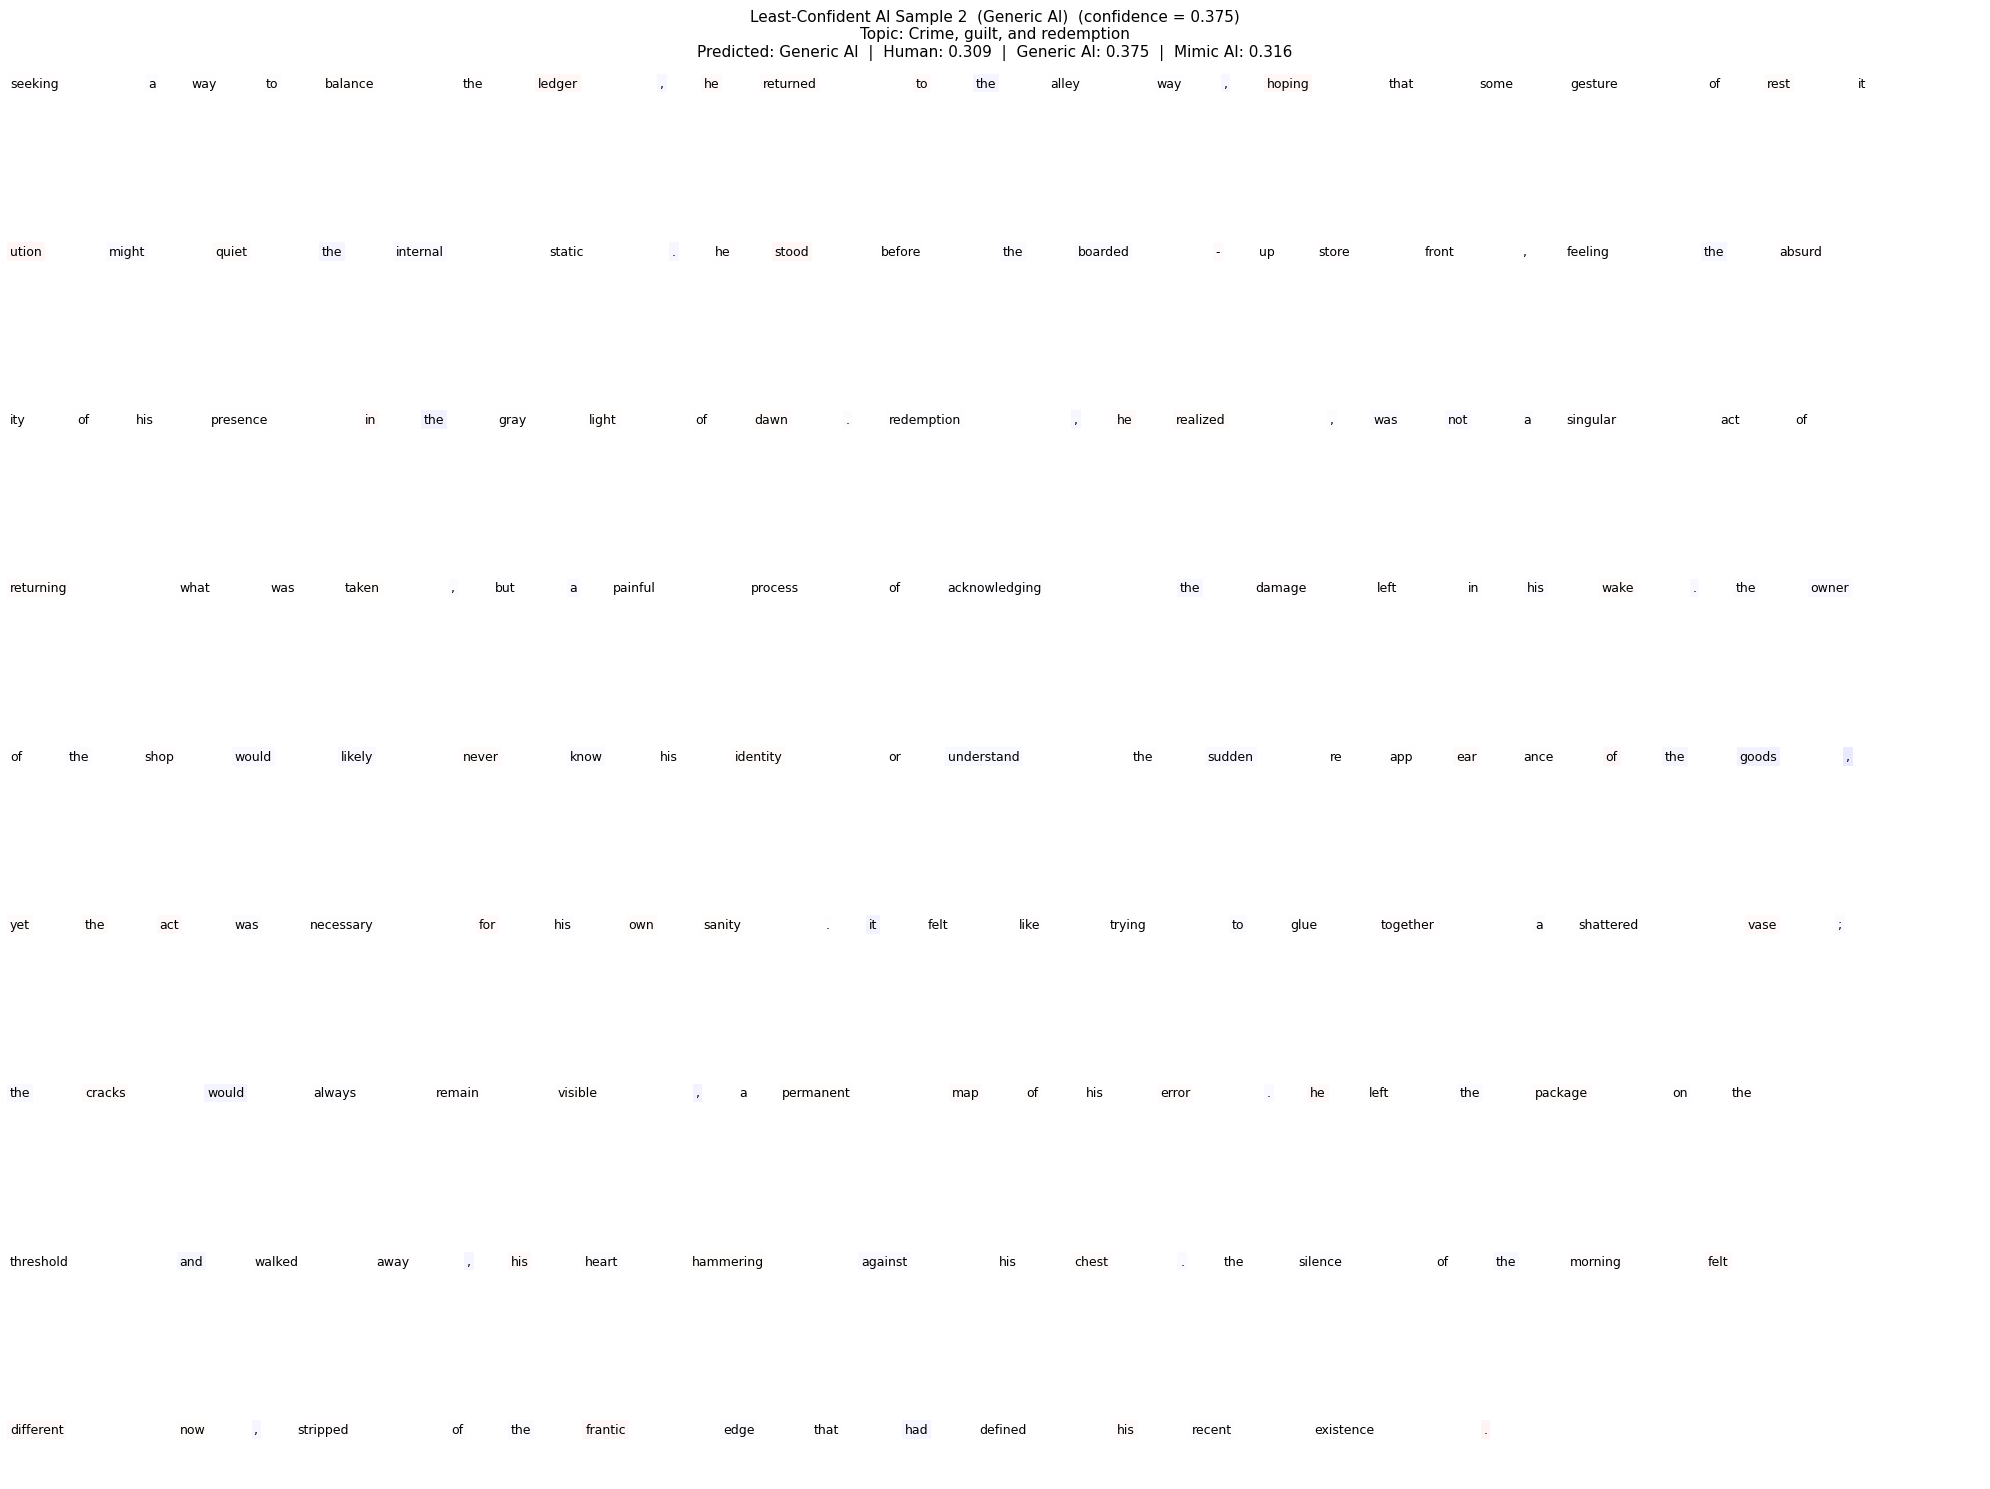


AI near-miss 3 (Generic AI) — delta: -0.01327


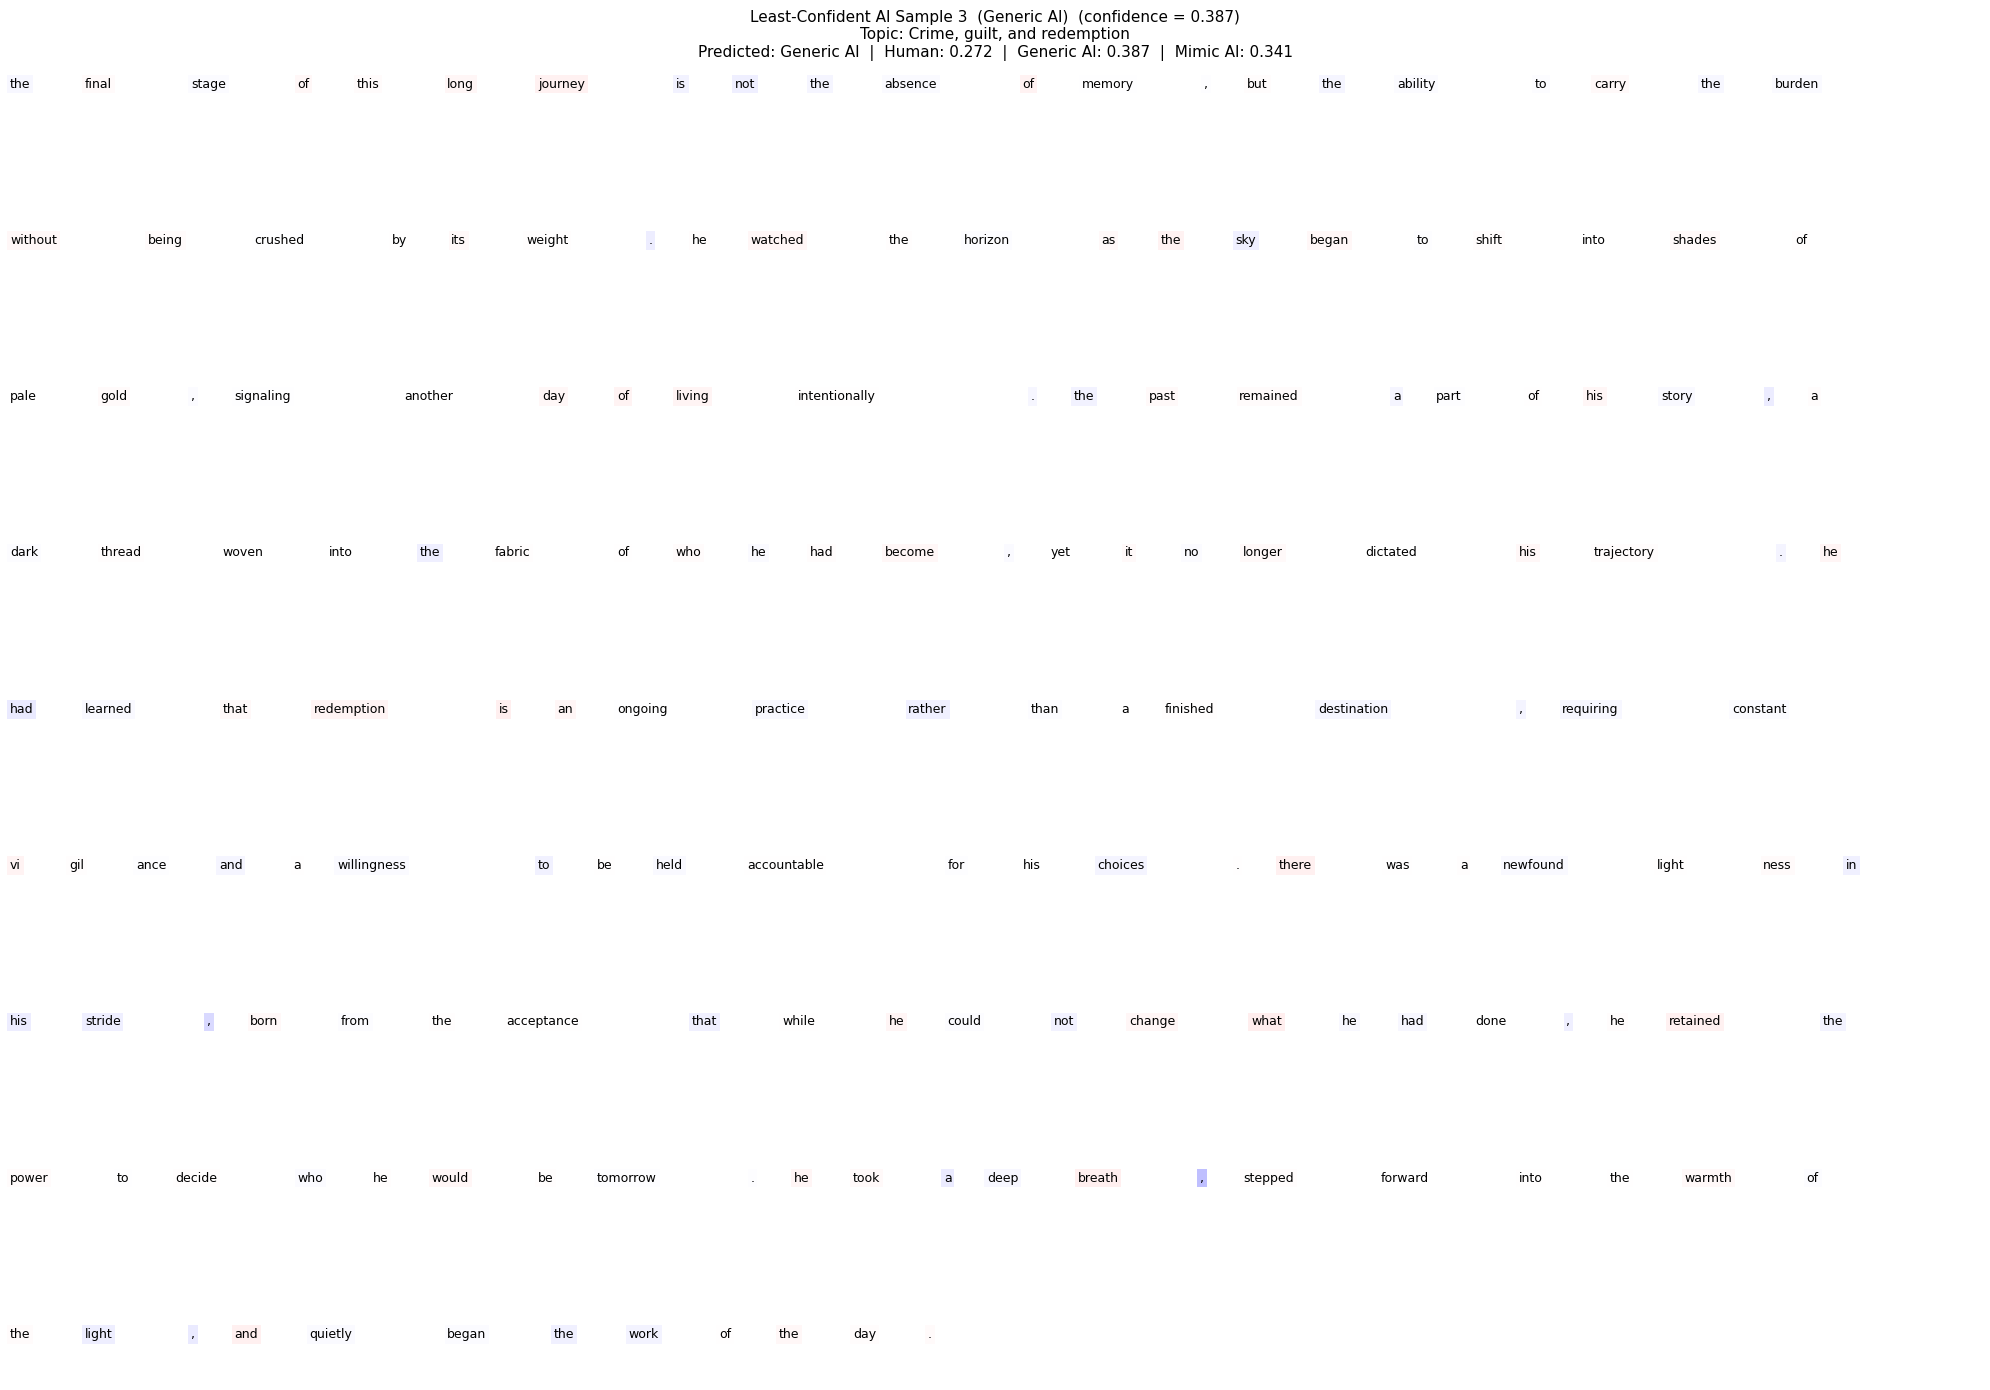

In [ ]:
print("Running attribution function on least-confident Human samples...")
for i, r in enumerate(least_conf_human):
    tokens, scores, pred, probs, delta = compute_attributions(r['text'])
    print(f"\nHuman near-miss {i+1} — delta: {delta:.5f}")
    visualize_attributions(
        tokens, scores, pred, probs,
        title=f'Least-Confident Human Sample {i+1}  (confidence = {r["confidence"]:.3f})\nTopic: {r["topic"]}',
        save_path=os.path.join(FIGURES_DIR, f'boundary_human_{i+1}.png')
    )

print("Running attribution function on least-confident AI samples...")
for i, r in enumerate(least_conf_ai):
    tokens, scores, pred, probs, delta = compute_attributions(r['text'])
    print(f"\nAI near-miss {i+1} ({label_names[r['true_label']]}) — delta: {delta:.5f}")
    visualize_attributions(
        tokens, scores, pred, probs,
        title=f'Least-Confident AI Sample {i+1}  ({label_names[r["true_label"]]})  (confidence = {r["confidence"]:.3f})\nTopic: {r["topic"]}',
        save_path=os.path.join(FIGURES_DIR, f'boundary_ai_{i+1}.png')
    )

### **Observations on Near-Miss Analysis:**

**Human near-misses (confidences 0.424-0.433):**

The most interesting thing I saw was that the three least-confident Human samples had Mimic AI as the second prediction (0.40–0.41). This means the model was confusing real Shelley's writing with the doppelgänger (AI-mimicked Shelley), and not with modern generic text.

The attributions plot of near-miss Human sample 3 shows Gothic vocabulary like "archangel", "devil", and "veins" in bright red, i.e., highly negatively attributed. These tokens were pushing the model away from its Human prediction. I think the model learned that intense Gothic language is a Mimic AI signal. So, when real Shelley used her most emotionally extreme passages, she accidentally triggered the same signal that the model associates with Mimic AI class.

**AI near-misses (confidences 0.372–0.387):**

All three least-confident AI samples came from the same topic: "Crime, guilt, and redemption." I don't think this is a coincidence because I expect this topic to naturally produce third-person past-tense narration ("he walked", "he realized"). In task 1, `past_tense_ratio` was the strongest discriminative feature. It seems that when Generic AI accidentally narrated a story about crime and guilt, it mimicked the most human-like syntactic feature in the dataset. Thus, the model probably got confused. 

The second near-miss AI sample showed a paragraph with past-tense third-person narration ("he returned to the alleyway", "he stood before the boarded store", "he walked away"). This obviously confused the model. Also, the first near-miss AI sample showed "soul" with negative attribution. It was Gothic vocabulary in generic AI prose, hence, pulling the prediction towards Human.

**Decision Boundary**

After all the mess that I have created in all these four tasks, I can say that the decision boundary is not where I would have drawn it at the end of Task-1. Generic AI that accidentally wrote in past tense got confused with human. The most gothic Shelley paragraphs got confused with Mimic AI. Sadly, my model did not learn human writing style in a deep sense. It learned some surface-level patterns like tense and vocabulary distribution that just happen to be in-line with class descriptions in my dataset. Thus, at the boundary, these patterns were not strong enough and my model's confidence crashed. 

I was excited to test my writings (including some of my previous SOPs) against the model, but it will not be of any use because the model has become a Victorian style detector. I am sure it will classify all my writings as AI.


---

### **5) Adversarial Test**

I just discussed where I think the decision boundary lies. An interesting thing to do now is to try and cross that boundary.
This idea of testing the boundary deliberately came partly from skimming through the [OUTFOX (Koike et al., 2023)](https://arxiv.org/pdf/2307.11729) paper. The Near-Miss analysis showed that the model was relying on surface-level patterns, but I wanted to see if I can break the model by playing with those patterns. [[7]](https://arxiv.org/pdf/2307.11729)

The authors of OUTFOX proposed a method where the attacker feeds the detector's own predictions back as in-context examples to an LLM, and instruct it to "generate text that this detector labels as Human". 
My version is much simpler but it follows the same principle. I do not need a full feedback loop because my Integrated Gradients analysis told me which surface features my model is using: past-tense verb ratio for Human, punctuation patterns for Generic AI, and complex Gothic vocabulary for Mimic AI. 

Therefore, I do not have to shoot in the dark at all. I will prompt [*DeepSeek-V3*](https://chat.deepseek.com)  to generate two paragraphs: one with modern AI-like vocabulary in past tense, and the other with Victorian vocabulary in present tense. If the model will detect the former as Human, then it will be confirmed that past tense is the "most exploitable surface feature", as OUTFOX authors call it, for the Human class. And if the model will detect the latter as Mimic AI, then I will infer that Victorian vocabulary without the correct tense cannot cross the Human-class boundary. [[8]](https://chat.deepseek.com)

In either case, I will be able to confirm that the model relies on surface-level patterns that can be manipulated, which is the main insight of the OUTFOX paper.

**Prompt for Test 1 (Modern english in past tense):**

"""

Generate a short literary paragraph (80–100 words) that I will use as a deliberate adversarial test for an AI text classifier. The paragraph must satisfy the following constraints, which I derived from Integrated Gradients saliency analysis of a DistilBERT classifier trained on Victorian human writing vs. AI-generated text:

Constraint 1: Every verb must be in simple past or past perfect tense (eg. "navigated", "encountered", "were approached"). Do not use any present-tense verbs because past tense is my model's most disciminative stylometric feature for predicting the text as "Human-written".

Constraint 2: The paragraph must naturally include at least 3 of the following words: "navigate", "framework", "context", "dynamics", "approach", "authentic". These words should appear as if written in a modern literary style.

Constraint 3: There should be no hint of Victorian-era vocabulary, no semicolons, no Gothic imagery, no exclamation marks. The setting and tone should be contemporary.

The test is to see if past-tense usage is alone sufficient to push the model predicting the generated text towards "Human-written", even when the vocabulary and style are modern.

"""

**Prompt for Test 2 (Victorian vocabulary in present tense):**

"""

Generate a short first-person perspective paragraph (80–100 words) in a Gothic literary style that I will use as a deliberate adversarial test for an AI text classifier. The paragraph must satisfy the following constraints:

Constraint 1: Every verb must be in present tense (I wander, beats, is, bloom). No past-tense verbs at all. This is the primary variable being tested because my analysis indicate that past-tense verb forms are the most discriminative feature for my model predicting "Human-written". 

Constraint 2: Include at least 3 of the following words in the paragraph: "melancholy", "sublime", "wretched", "desolate", "despair". These words should be integrated naturally into the narrative. 

Constraint 3: Use comma splices and comma-separated descriptive phrases rather than semicolons. I want the vocabulary to read "Human" but the punctuation structure to read "AI-generated".

This tests whether Victorian vocabulary without the past-tense structure, is sufficient for my model to predict "Human-written". 

"""

I will paste the outputs of these two prompts in the next code cell.

In [ ]:
# Test 1: Modern English prose, written entirely in past tense
# I want to test whether past-tense alone flips an AI-vocabulary paragraph to Human
test_past_tense = """
She navigated the complex social framework carefully,
aware that each interaction carried weight beyond its surface meaning.
The systems she encountered were designed to reward compliance
rather than authentic expression. She approached each challenge
with deliberate caution, understanding that the dynamics at play
were shaped by centuries of accumulated expectation.
She found no simple resolution, only an ongoing negotiation
between what she was and what the context demanded of her.
"""

# Test 2: Victorian vocabulary, but written in present tense
# I want to test whether Victorian vocabulary alone fools the model without past tense
test_victorian_vocab = """
I wander through the desolate corridors of my melancholy,
the wretched countenance of my despair reflected in every surface.
The sublime terror of my isolation is not, I confess,
without its peculiar beauty — a beauty born of suffering,
as the finest flowers bloom nearest the grave.
My heart, long accustomed to its solitary vigil,
beats on with stubborn persistence against the gathering dark.
"""

# Test 3: Real Shelley text 
# The model should classify as Human
test_real_shelley = """
A tingling long-lost sense of pleasure often came across me during this
journey. Some turn in the road, some new object suddenly perceived and
recognised, reminded me of days gone by, and were associated with the
lighthearted gaiety of boyhood. The very winds whispered in soothing
accents, and maternal Nature bade me weep no more. Then again the
kindly influence ceased to act—I found myself fettered again to grief
and indulging in all the misery of reflection.
"""

tests = [
    ('Test 1 — Modern past-tense prose',               test_past_tense),
    ('Test 2 — Victorian vocabulary, present tense',    test_victorian_vocab),
    ('Test 3 — Real Shelley text (ground truth check)', test_real_shelley),
]

print("--- ADVERSARIAL PROBE RESULTS ---\n")
for name, text in tests:
    pred, probs = get_prediction(text)
    print(f"{name}")
    print(f"  Prediction : {label_names[pred]}")
    print(f"  P(Human) = {probs[0]:.4f}  |  P(GenAI) = {probs[1]:.4f}  |  P(MimicAI) = {probs[2]:.4f}")
    print()

--- ADVERSARIAL PROBE RESULTS ---

Test 1 — Modern past-tense prose
  Prediction : Generic AI
  P(Human) = 0.2403  |  P(GenAI) = 0.4679  |  P(MimicAI) = 0.2919

Test 2 — Victorian vocabulary, present tense
  Prediction : Mimic AI
  P(Human) = 0.3303  |  P(GenAI) = 0.1983  |  P(MimicAI) = 0.4714

Test 3 — Real Shelley text (ground truth check)
  Prediction : Human
  P(Human) = 0.4247  |  P(GenAI) = 0.1938  |  P(MimicAI) = 0.3815



Test 1 — Modern past-tense prose
  Convergence delta: 0.00859


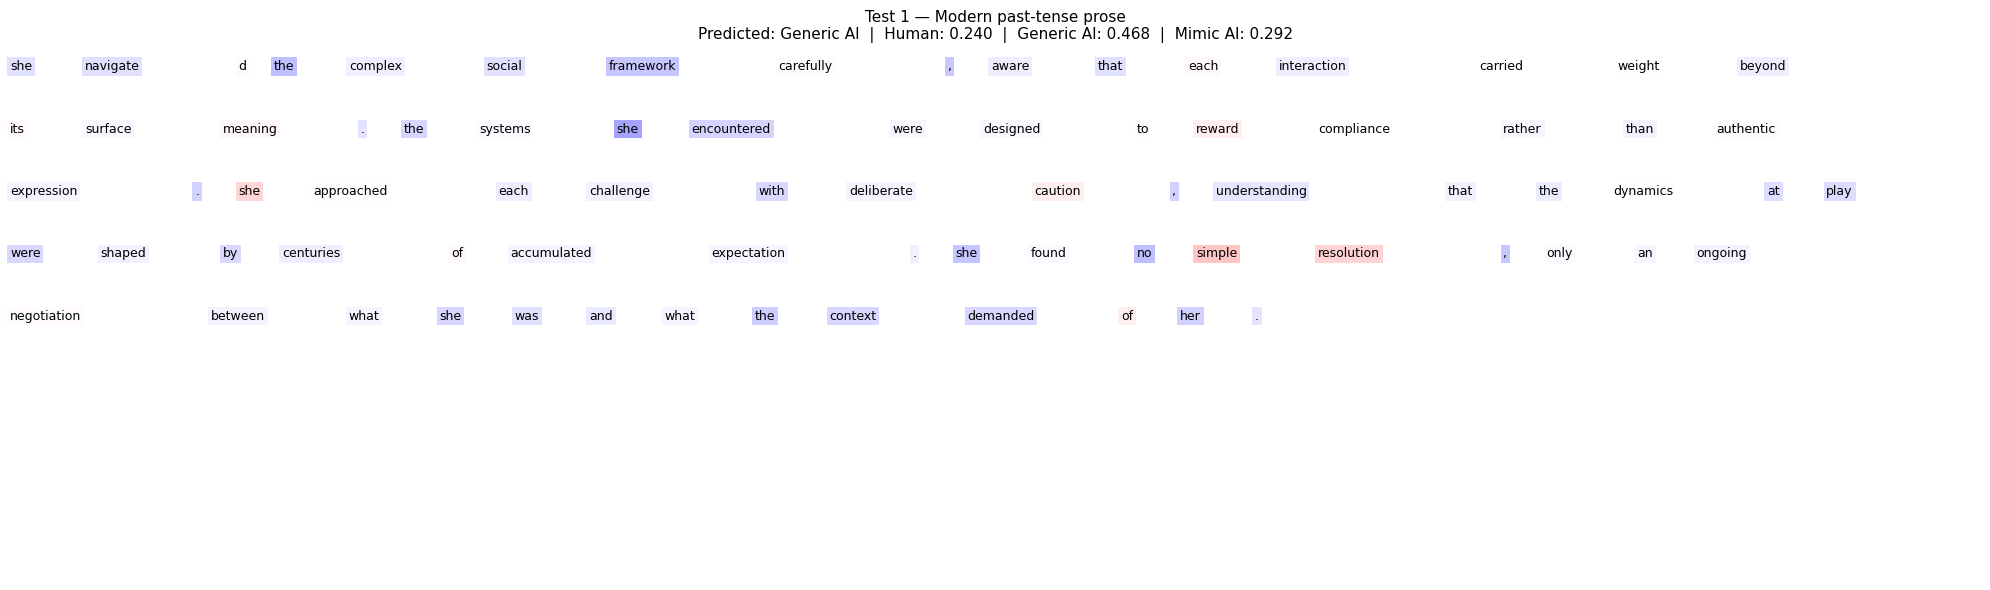

  Top positive tokens: ['she', 'the', 'no', 'she', ',', 'framework', ',', 'the']

Test 2 — Victorian vocabulary, present tense
  Convergence delta: 0.02117


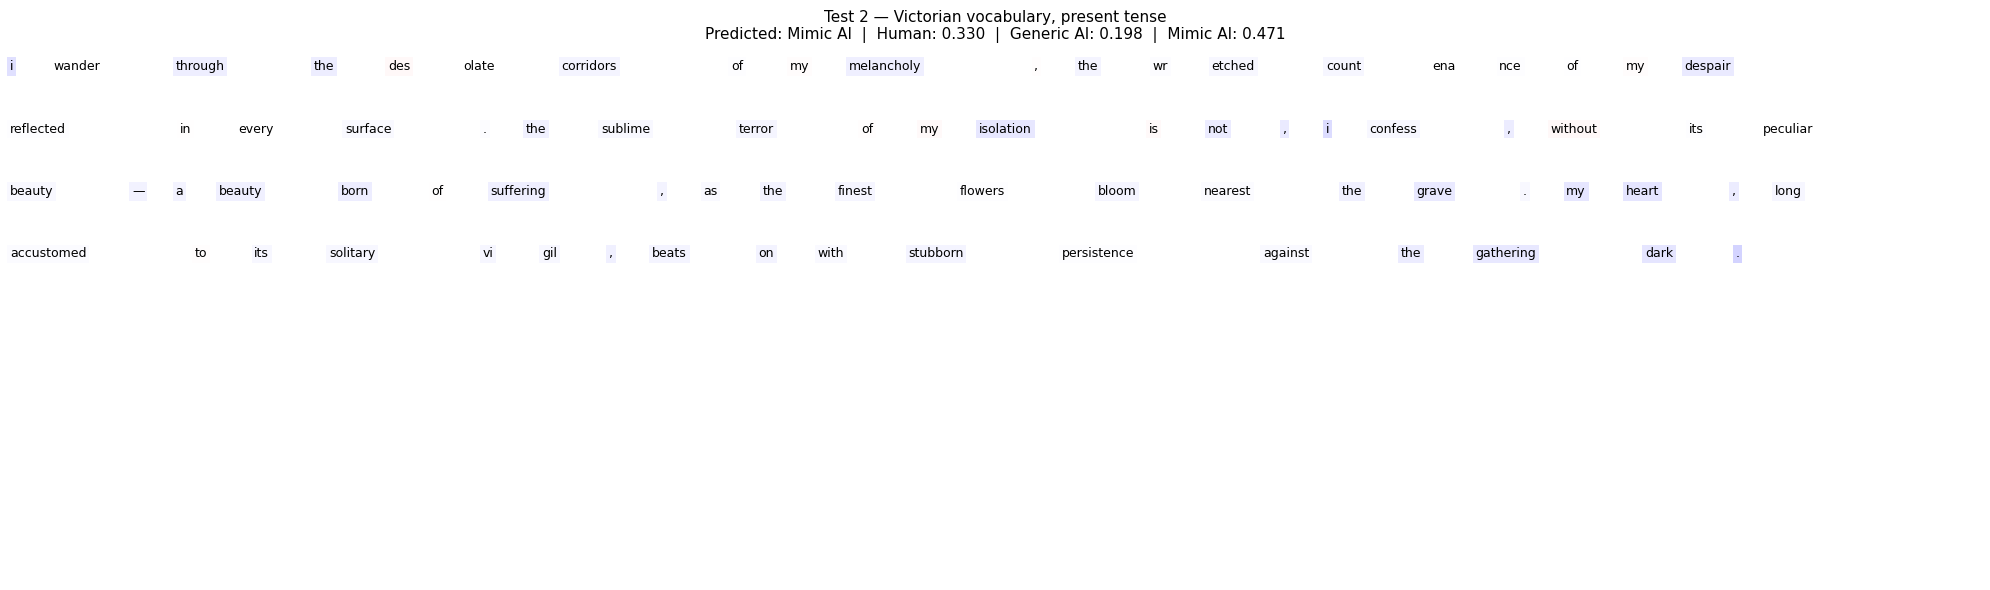

  Top positive tokens: ['.', 'i', 'i', 'heart', 'dark', 'my', 'isolation', 'gathering']



In [13]:
# Running attribution on the two diagnostically informative tests
for name, text, filename in [
    ('Test 1 — Modern past-tense prose',             test_past_tense,      'test_past_tense'),
    ('Test 2 — Victorian vocabulary, present tense', test_victorian_vocab, 'test_victorian'),
]:
    tokens, scores, pred, probs, delta = compute_attributions(text)
    print(f"{name}")
    print(f"  Convergence delta: {delta:.5f}")
    visualize_attributions(
        tokens, scores, pred, probs,
        title=name,
        save_path=os.path.join(FIGURES_DIR, f'{filename}_attribution.png')
    )
    print(f"  Top positive tokens: {[t for t, s in get_top_tokens(tokens, scores, n=8)]}")
    print()

### **Observations on Adversarial Test:**

**Test 1 (Modern vocabulary with past tense)** was predicted as Generic AI with a confidence of 0.468. Contrary to what I thought, modern AI-like proses in past tense did not fool the model. The vocabulary flagged in blue as Generic AI signals were "framework", "dynamics", "navigate", "compliance", etc. This means that past tense is necessary for Human classification but not sufficient, because it also needs to have the right lexical style.

**Test 2 (Victorian vocabulary with present tense)** was predicted as Mimic AI with a confidence of 0.471. Gothic vocabulary like "isolation", "dark", "heart" were positively attributed, but without past tense, it ended up in the Mimic AI region rather than the Human class. My Class 3 generation prompt asked Gemini for Victorian vocabulary in present tense, and the model actually learned that combination as the Mimic AI signature. 

I guess it is clear now that to fool the model, I will need Victorian vocabulary AND past-tense narration along with complex syntactic structures.

**Conclusion**

The detector is not naive in the way I expected. Changing one surface feature (tense alone or vocabulary alone) will not flip the 
classification. Thus, the decision boundary requires multiple features to align simultaneously. This is probably why the near-miss analysis showed that even the model's least confident correct predictions still landed in the correct class, just with lower confidence. 

The limitation is also different from what I expected. My model is not capable of detecting AI-generated texts in general because the features it learned (past tense, Victorian vocabulary, punctuation patterns) are speicific to my dataset. 

Now, Task 4 is about testing if a Genetic Algorithm will be able to fool the model by optimizing across all features simultaneously rather than attacking them one at a time. 

### **References**

[Github Copilot Assistant](https://github.com/copilot) came in clutch with the Saliency Analysis code structure and syntax as I was jumping from one implementation to another, be it Captum's documentations, tutorials, or online walkthroughs. I have never implemented Integrated Gradients before and this was a good starting point for me. The AI-isms Investigation and Near Miss analysis section codes were just a bit more custom and I wrote them down but Copilot's suggestions were accurate on the structure. 

I would like to give a big shout to [Bohrium AI](https://www.bohrium.com/en) for helping me figure out the exact sections of the OUTFOX paper that are releevant to my scope. I discovered the paper through a Kaggle discussion and went through the sections that Bohrium suggested.
Finally, as cited, I used [DeepSeek-V3](https://chat.deepseek.com) for generating the adversarial test paragraphs. [[9]](https://www.bohrium.com/en)

All citations (hyperlinked inline throughout the notebook) are listed here in full:

1. Sundararajan, M., Taly, A., & Yan, Q. (2017). Axiomatic attribution for deep networks. In International Conference on Machine Learning (pp. 3319-3328). PMLR. https://arxiv.org/pdf/1703.01365

2. Deep Dive into Neural Network Explanations with Integrated Gradients. Towards Data Science. https://towardsdatascience.com/deep-dive-into-neural-network-explanations-with-integrated-gradients-7f4b7be855a2/

3. Kaggle Discussion on Integrated Gradients. https://www.kaggle.com/discussions/general/226092

4. Captum Integrated Gradients API. https://captum.ai/api/layer.html

5. Using Captum for Interpreting PyTorch Models in Production. Medium. https://medium.com/@nivedhithadm/using-captum-for-interpreting-pytorch-models-in-production-ddf91fbbd3fd

6. Captum Tutorial on BERT SQuAD Interpretation. https://captum.ai/tutorials/Bert_SQUAD_Interpret

7. OUTFOX: A Benchmark for Evaluating and Enhancing the Robustness of LLM Detectors. Koike et al., 2023. https://arxiv.org/pdf/2307.11729

8. Chat with DeepSeek-V3 for Adversarial Test texts generation. https://chat.deepseek.com

9. Research assistance with Bohrium AI. https://www.bohrium.com/en